#  Machine Learning Capstone Project

##  Thanaweya Amma 2022 Dataset
### Preprocessing Pipeline & Faculty Recommendation Model

**Project Objective**

Develop a machine learning model that predicts the most suitable faculty category for Egyptian Thanaweya Amma students based on their academic performance, track, skills, and interests. The project includes comprehensive data preprocessing, feature engineering, model development, hyperparameter tuning, evaluation, and deployment as a recommendation system.

---


- Outlier **capping was removed entirely** — a student's real high/low subject grades are exactly the signal a college-recommendation model needs, so clipping them destroys information rather than cleaning noise.
- All preprocessing (structural imputation, feature engineering, encoding, selective power-transform, scaling, feature selection) is wrapped in scikit-learn **`Pipeline`**s of custom transformers, fit once on the training split only and reused as-is at inference time — no hand-repeated `X_train`/`X_test` code, no leakage.
- **Two classifiers compared**: `RandomForestClassifier` (baseline + `RandomizedSearchCV`-tuned) and `CatBoostClassifier`, scored on accuracy, weighted precision/recall/F1, and a confusion matrix each.
- Feature selection is three passes, all fit on the training fold only: near-zero-variance, then correlation-pruning (`|corr| > 0.90`), then RandomForest-importance top-K.
- The classifier never sees `Skills`/`Interests`; a separate `profile_pipeline` multi-hot encodes them for the recommender's content-based similarity score only (see the Recommendation System section).
- Every preprocessing step is justified for *this* data rather than applied by default (see the markdown notes before each step).

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
sns.set_theme()

pd.set_option('display.max_columns', 100)

## Load Data

In [2]:
data = pd.read_csv("/content/thanaweya_final_with_profiles_modified.csv", on_bad_lines='skip', engine='python')
print(data.shape)
data.head()

(24115, 22)


,branch,Percentage,status,arabic,first_foreign_lang,second_foreign_lang,pure_mathematics,history,geography,philosophy,psychology,chemistry,biology,geology,applied_math,physics,total,Track,Faculty,Faculty_Category,Skills,Interests
0,أدبي,87.80,ناجح,61.0,27.0,34.0,NaN,58.0,60.0,60.0,60.0,NaN,NaN,NaN,NaN,NaN,360.0,Literary Track,Economics and Science Political Cairo,Economics,"Communication, Data Analysis, Critical Thinking","Technology, Learning, Personal Development"
1,علمي علوم,57.32,ناجح,47.0,25.0,26.0,NaN,NaN,NaN,NaN,NaN,30.0,30.0,44.0,NaN,33.0,235.0,Scientific - Science Track,No Faculty,Other,"Communication, Problem Solving, Teamwork","Technology, Learning, Personal Development"
2,أدبي,83.41,ناجح,70.0,38.0,NaN,NaN,60.0,60.0,60.0,54.0,NaN,NaN,NaN,NaN,NaN,342.0,Literary Track,Politics and Economics Beni Suef,Economics,"Communication, Research, Statistics","Technology, Learning, Personal Development"
3,أدبي,53.17,ناجح,57.0,27.0,NaN,NaN,43.0,31.0,30.0,30.0,NaN,NaN,NaN,NaN,NaN,218.0,Literary Track,No Faculty,Other,"Communication, Problem Solving, Teamwork","Technology, Learning, Personal Development"
4,علمي رياضة,51.46,دور ثاني,56.0,25.0,6.0,30.0,NaN,NaN,NaN,NaN,30.0,NaN,NaN,33.0,31.0,211.0,Scientific - Math Track,No Faculty,Other,"Communication, Problem Solving, Teamwork","Technology, Learning, Personal Development"


In [3]:
data.tail()

,branch,Percentage,status,arabic,first_foreign_lang,second_foreign_lang,pure_mathematics,history,geography,philosophy,psychology,chemistry,biology,geology,applied_math,physics,total,Track,Faculty,Faculty_Category,Skills,Interests
24110,علمي رياضة,81.71,ناجح,57.0,42.0,40.0,47.0,NaN,NaN,NaN,NaN,54.0,NaN,NaN,51.0,44.0,335.0,Scientific - Math Track,Al-Alsun (Languages) Sohag,Languages (Al-Alsun),"Cultural Awareness, Translation, Languages","Technology, Learning, Personal Development"
24111,علمي رياضة,70.24,دور ثاني,48.0,40.0,35.0,48.0,NaN,NaN,NaN,NaN,45.0,NaN,NaN,42.0,30.0,288.0,Scientific - Math Track,Education Early Childhood Kafr Sheikh,Early Childhood Education,"Child Care, Communication, Patience","Technology, Learning, Personal Development"
24112,علمي رياضة,66.59,ناجح,60.0,39.0,28.0,33.0,NaN,NaN,NaN,NaN,42.0,NaN,NaN,35.0,36.0,273.0,Scientific - Math Track,Education Early Childhood Early Cairo,Early Childhood Education,"Communication, Psychology, Child Care","Technology, Learning, Personal Development"
24113,علمي رياضة,51.95,ناجح,40.0,28.0,24.0,30.0,NaN,NaN,NaN,NaN,30.0,NaN,NaN,30.0,31.0,213.0,Scientific - Math Track,No Faculty,Other,"Communication, Problem Solving, Teamwork","Technology, Learning, Personal Development"
24114,علمي رياضة,67.56,ناجح,55.0,31.0,32.0,36.0,NaN,NaN,NaN,NaN,41.0,NaN,NaN,42.0,40.0,277.0,Scientific - Math Track,Commerce Affiliated (Distance Program) Asyut,Co,None,None


## Data Cleaning

In [4]:
data.columns

Index(['branch', 'Percentage', 'status', 'arabic', 'first_foreign_lang',
       'second_foreign_lang', 'pure_mathematics', 'history', 'geography',
       'philosophy', 'psychology', 'chemistry', 'biology', 'geology',
       'applied_math', 'physics', 'total', 'Track', 'Faculty',
       'Faculty_Category', 'Skills', 'Interests'],
      dtype='object')

1. Drop `branch` — repetitive, we already have `Track`.
2. Drop `Faculty` — we only care about the `Faculty_Category`, not the specific faculty name.
3. Drop `Percentage` — redundant with `total` (same information, keeping both introduces multicollinearity).

In [5]:
col_drop = ['branch', 'Faculty', 'Percentage']
data = data.drop(columns=col_drop)
print(data.shape)

(24115, 19)


Each row now represents a student: subject grades, total degree, Track, status, Faculty category, and free-text skills/interests.

In [6]:
data.columns

Index(['status', 'arabic', 'first_foreign_lang', 'second_foreign_lang',
       'pure_mathematics', 'history', 'geography', 'philosophy', 'psychology',
       'chemistry', 'biology', 'geology', 'applied_math', 'physics', 'total',
       'Track', 'Faculty_Category', 'Skills', 'Interests'],
      dtype='object')

No duplicate rows:

In [7]:
data.duplicated().sum()

np.int64(0)

### Nulls in the data

In [8]:
null_counts = data.isnull().sum()
null_percentages = (data.isnull().sum() / len(data)) * 100
null_info = pd.DataFrame({'Null Count': null_counts, 'Null Percentage': null_percentages})
print(null_info[null_info['Null Count'] > 0].sort_values(by='Null Percentage', ascending=False))

                     Null Count  Null Percentage
pure_mathematics          19562        81.119635
applied_math              19559        81.107195
biology                   15420        63.943604
geology                   15415        63.922870
history                   13350        55.359735
psychology                13349        55.355588
geography                 13345        55.339001
philosophy                13345        55.339001
physics                   10928        45.316193
chemistry                 10906        45.224964
second_foreign_lang         251         1.040846
first_foreign_lang          111         0.460294
arabic                       94         0.389799
Skills                        1         0.004147
Interests                     1         0.004147


In [9]:
data.isnull().sum().sum()

np.int64(145637)

### Status column

Three categories: pass, fail, second round. Only successful (passed) students are relevant for a *college* recommendation.

In [10]:
status_counts = data['status'].value_counts()
status_percentages = (data['status'].value_counts(normalize=True) * 100).round(2)
status_info = pd.DataFrame({'Count': status_counts, 'Percentage': status_percentages})
print(status_info)

          Count  Percentage
status                     
ناجح      16872       69.96
دور ثاني   5184       21.50
راسب       2059        8.54


In [11]:
status_to_drop = ['راسب', 'دور ثاني']
data = data[~data['status'].isin(status_to_drop)]
print(data['status'].value_counts())
print(data.shape)

status
ناجح    16872
Name: count, dtype: int64
(16872, 19)


In [12]:
data.isnull().sum().sum()

np.int64(101348)

The remaining nulls are distributed across track-specific subjects — that's structural (a Literacy-track student was never examined in Chemistry), not a data quality problem, and is handled during feature engineering below, not by dropping rows.

In [13]:
null_counts = data.isnull().sum()
null_percentages = (data.isnull().sum() / len(data)) * 100
null_info = pd.DataFrame({'Null Count': null_counts, 'Null Percentage': null_percentages})
print(null_info[null_info['Null Count'] > 0].sort_values(by='Null Percentage', ascending=False))

                     Null Count  Null Percentage
pure_mathematics          13567        80.411332
applied_math              13567        80.411332
geology                   11035        65.404220
biology                   11035        65.404220
geography                  9142        54.184448
history                    9142        54.184448
philosophy                 9142        54.184448
psychology                 9142        54.184448
chemistry                  7730        45.815552
physics                    7730        45.815552
second_foreign_lang         114         0.675676
Skills                        1         0.005927
Interests                     1         0.005927


`status` now has zero variance (everyone left is a pass) — drop it.

In [14]:
data = data.drop(columns=['status'])
print(data.columns)

Index(['arabic', 'first_foreign_lang', 'second_foreign_lang',
       'pure_mathematics', 'history', 'geography', 'philosophy', 'psychology',
       'chemistry', 'biology', 'geology', 'applied_math', 'physics', 'total',
       'Track', 'Faculty_Category', 'Skills', 'Interests'],
      dtype='object')


In [15]:
data.sample(10)

,arabic,first_foreign_lang,second_foreign_lang,pure_mathematics,history,geography,philosophy,psychology,chemistry,biology,geology,applied_math,physics,total,Track,Faculty_Category,Skills,Interests
14318,65.0,33.0,24.0,30.0,NaN,NaN,NaN,NaN,38.0,NaN,NaN,34.0,43.0,267.0,Scientific - Math Track,Education,"Communication, Presentation, Teaching","Learning, Helping Students, Child Development"
12428,41.0,32.0,20.0,NaN,36.0,30.0,42.0,43.0,NaN,NaN,NaN,NaN,NaN,244.0,Literary Track,Social Service,"Communication, Problem Solving, Teamwork","Technology, Learning, Personal Development"
18253,45.0,37.0,33.0,NaN,NaN,NaN,NaN,NaN,30.0,31.0,47.0,NaN,32.0,255.0,Scientific - Science Track,Education,"Organization, Communication, Presentation","Child Development, Helping Students, Learning"
12547,67.0,38.0,38.0,NaN,NaN,NaN,NaN,NaN,56.0,51.0,56.0,NaN,54.0,360.0,Scientific - Science Track,Computers and Information,"Programming, Database Management, Technology","Artificial Intelligence, Data, Cybersecurity"
10014,64.0,28.0,26.0,NaN,43.0,44.0,47.0,46.0,NaN,NaN,NaN,NaN,NaN,298.0,Literary Track,Education,"Presentation, Teaching, Organization","Learning, Child Development, Helping Students"
14975,49.0,30.0,20.0,NaN,36.0,42.0,41.0,40.0,NaN,NaN,NaN,NaN,NaN,258.0,Literary Track,Education,"Presentation, Leadership, Patience","Teaching, Child Development, Helping Students"
15850,71.0,49.0,39.0,48.0,NaN,NaN,NaN,NaN,31.0,NaN,NaN,54.0,54.0,346.0,Scientific - Math Track,Technical Health Institute,"Communication, Problem Solving, Teamwork","Technology, Learning, Personal Development"
574,57.0,34.0,32.0,NaN,NaN,NaN,NaN,NaN,30.0,30.0,44.0,NaN,30.0,257.0,Scientific - Science Track,Arts,"Writing, Research, Analysis","Culture, Creativity, History"
6075,45.0,30.0,38.0,NaN,NaN,NaN,NaN,NaN,30.0,30.0,46.0,NaN,30.0,249.0,Scientific - Science Track,Arts,"Research, Critical Thinking, Analysis","Writing, Creativity, History"
7592,65.0,47.0,36.0,30.0,NaN,NaN,NaN,NaN,36.0,NaN,NaN,43.0,42.0,299.0,Scientific - Math Track,Agriculture,"Agricultural Technology, Field Work, Biology","Food Security, Farming Technology, Nature"


### Track column — shorten labels

In [16]:
data['Track'].value_counts()

,count
Track,
Literary Track,7730
Scientific - Science Track,5837
Scientific - Math Track,3305


In [17]:
track_mapping = {
    'Scientific - Science Track': 'Science',
    'Literary Track': 'Literacy',
    'Scientific - Math Track': 'Math'
}
data['Track'] = data['Track'].map(track_mapping)
print(data['Track'].value_counts())

Track
Literacy    7730
Science     5837
Math        3305
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)

Track distribution is imbalanced (expected — Science track is the most common):

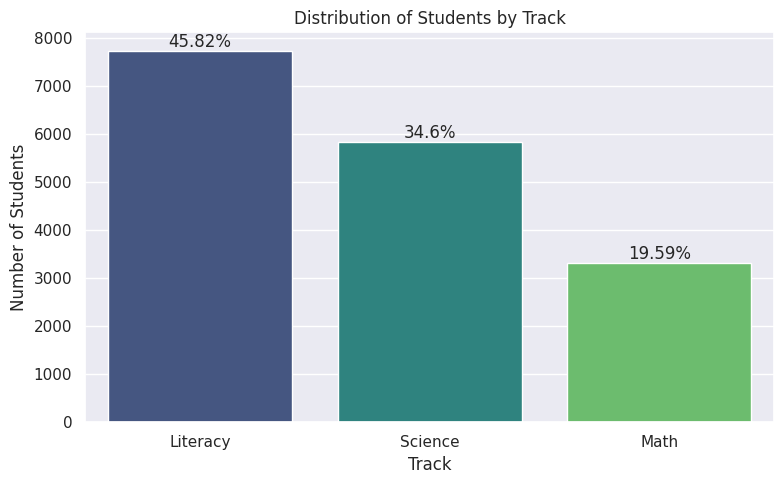

In [18]:
track_counts = data['Track'].value_counts()
track_percentages = (data['Track'].value_counts(normalize=True) * 100).round(2)

plt.figure(figsize=(8, 5))
sns.barplot(x=track_counts.index, y=track_counts.values, hue=track_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Students by Track')
plt.xlabel('Track')
plt.ylabel('Number of Students')
for i, v in enumerate(track_counts.values):
    plt.text(i, v, f'{track_percentages.iloc[i]}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()

`Faculty_Category` (our target) — also imbalanced, this drives several downstream choices (stratified split, `class_weight`/`sample_weight`, Top-3 accuracy as the headline metric):

In [19]:
faculty_counts = data['Faculty_Category'].value_counts()
faculty_percentages = (data['Faculty_Category'].value_counts(normalize=True) * 100).round(2)
faculty_info = pd.DataFrame({'Count': faculty_counts, 'Percentage': faculty_percentages})
print(faculty_info)

                               Count  Percentage
Faculty_Category                                
Other                           2964       17.57
Education                       2754       16.32
Commerce                        1552        9.20
Law                             1402        8.31
Arts                            1290        7.65
Early Childhood Education       1064        6.31
Archaeology                      575        3.41
Agriculture                      555        3.29
Economics                        464        2.75
Science                          445        2.64
Languages (Al-Alsun)             391        2.32
Sports Education                 361        2.14
Medicine                         357        2.12
Nursing                          347        2.06
Engineering                      334        1.98
Tourism and Hotels               317        1.88
Medicine Veterinary              245        1.45
Mass Communication               208        1.23
Computers and Inform

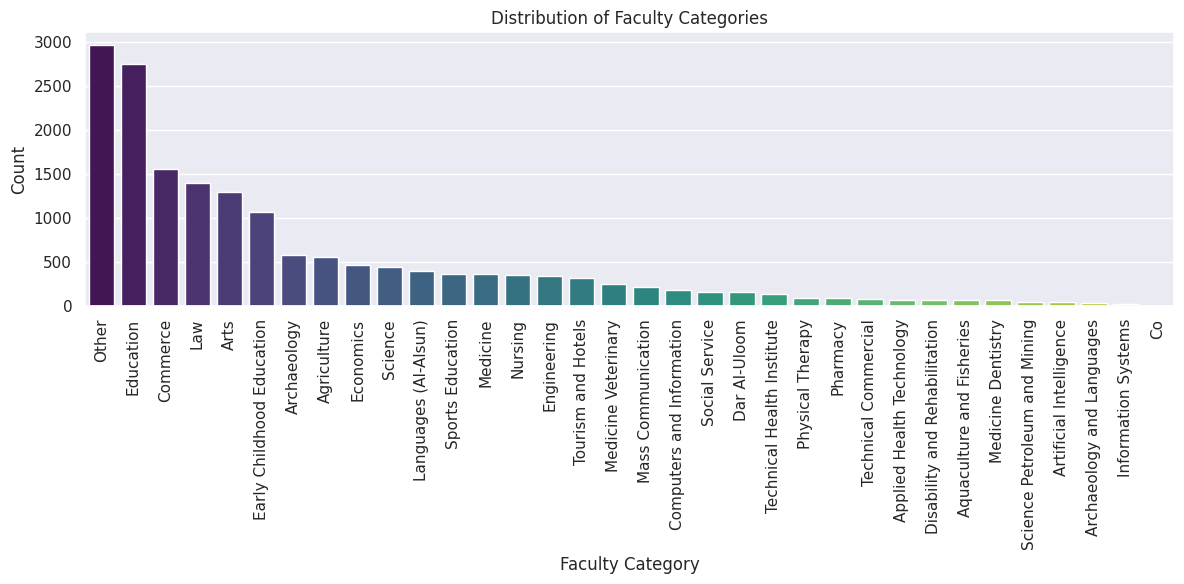

In [20]:
plt.figure(figsize=(12, 6))
sns.barplot(x=faculty_counts.index, y=faculty_counts.values, hue=faculty_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Faculty Categories')
plt.xlabel('Faculty Category')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [21]:
data.shape

(16872, 18)

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16872 entries, 0 to 24114
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   arabic               16872 non-null  float64
 1   first_foreign_lang   16872 non-null  float64
 2   second_foreign_lang  16758 non-null  float64
 3   pure_mathematics     3305 non-null   float64
 4   history              7730 non-null   float64
 5   geography            7730 non-null   float64
 6   philosophy           7730 non-null   float64
 7   psychology           7730 non-null   float64
 8   chemistry            9142 non-null   float64
 9   biology              5837 non-null   float64
 10  geology              5837 non-null   float64
 11  applied_math         3305 non-null   float64
 12  physics              9142 non-null   float64
 13  total                16872 non-null  float64
 14  Track                16872 non-null  object 
 15  Faculty_Category     16872 non-null  obje

Nulls in `arabic` / `first_foreign_lang` / `second_foreign_lang` are common to every track, so a small fraction here reflects a real zero mark / absence rather than a structural gap:

In [23]:
null_rows = data[data['arabic'].isnull() | data['first_foreign_lang'].isnull() | data['second_foreign_lang'].isnull()]
print('Rows with nulls in arabic / first_foreign_lang / second_foreign_lang:', len(null_rows))
null_rows.sample(min(4, len(null_rows)))

Rows with nulls in arabic / first_foreign_lang / second_foreign_lang: 114


,arabic,first_foreign_lang,second_foreign_lang,pure_mathematics,history,geography,philosophy,psychology,chemistry,biology,geology,applied_math,physics,total,Track,Faculty_Category,Skills,Interests
76,48.0,33.0,NaN,NaN,51.0,53.0,54.0,40.0,NaN,NaN,NaN,NaN,NaN,279.0,Literacy,Commerce,"Finance, Business Analysis, Organization","Finance, Management, Business"
36,60.0,25.0,NaN,NaN,47.0,52.0,60.0,48.0,NaN,NaN,NaN,NaN,NaN,292.0,Literacy,Commerce,"Problem Solving, Communication, Accounting","Business, Management, Finance"
19,59.0,41.0,NaN,NaN,55.0,53.0,42.0,40.0,NaN,NaN,NaN,NaN,NaN,290.0,Literacy,Arts,"Writing, Analysis, Creativity","Writing, History, Culture"
59,56.0,35.0,NaN,NaN,58.0,57.0,40.0,38.0,NaN,NaN,NaN,NaN,NaN,284.0,Literacy,Early Childhood Education,"Psychology, Creativity, Teaching","Technology, Learning, Personal Development"


Skills and Interests are free-text, comma-separated, high-cardinality columns:

In [24]:
data['Skills'].sample(10)

,Skills
16964,"Problem Solving, Design, Logical Thinking"
17811,"Communication, Problem Solving, Teamwork"
244,"Organization, Management, Business Analysis"
9528,"Communication, Problem Solving, Teamwork"
21181,"Project Management, Logical Thinking, Problem ..."
18642,"Communication, Problem Solving, Teamwork"
4539,"Patience, Creativity, Teaching"
19852,"Organization, Accounting, Management"
3580,"Psychology, Patience, Teaching"
22851,"Attention to Detail, Scientific Analysis, Prob..."


In [25]:
data['Interests'].sample(10)

,Interests
3605,"Technology, Learning, Personal Development"
6442,"Child Development, Helping Students, Teaching"
15614,"Creativity, History, Culture"
6224,"Technology, Learning, Personal Development"
20791,"Food Security, Environment, Nature"
21973,"Justice, Debate, Public Service"
5564,"Technology, Learning, Personal Development"
3989,"Technology, Learning, Personal Development"
6245,"Technology, Learning, Personal Development"
7852,"Technology, Learning, Personal Development"


In [26]:
data.describe(include='object').T

,count,unique,top,freq
Track,16872,3,Literacy,7730
Faculty_Category,16872,34,Other,2964
Skills,16871,2204,"Communication, Problem Solving, Teamwork",5027
Interests,16871,347,"Technology, Learning, Personal Development",8098


Mean and median are close for most numeric columns — no extreme skew, distributions are roughly symmetric:

In [27]:
data.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
arabic,16872.0,54.598684,9.403802,40.0,47.0,54.0,62.0,79.0
first_foreign_lang,16872.0,37.269322,7.517520,25.0,31.0,38.0,44.0,50.0
second_foreign_lang,16758.0,30.878118,6.592085,20.0,25.0,32.0,37.0,40.0
pure_mathematics,3305.0,39.720121,8.842859,30.0,31.0,38.0,47.0,60.0
history,7730.0,37.758409,7.641380,30.0,30.0,36.0,43.0,60.0
geography,7730.0,38.532988,7.241666,30.0,32.0,38.0,43.0,60.0
philosophy,7730.0,42.495602,6.279989,30.0,38.0,43.0,47.0,60.0
psychology,7730.0,41.410414,5.275968,30.0,38.0,42.0,45.0,60.0
chemistry,9142.0,41.727521,9.245490,30.0,33.0,41.0,49.0,60.0
biology,5837.0,37.031694,6.803199,30.0,30.0,35.0,42.0,60.0


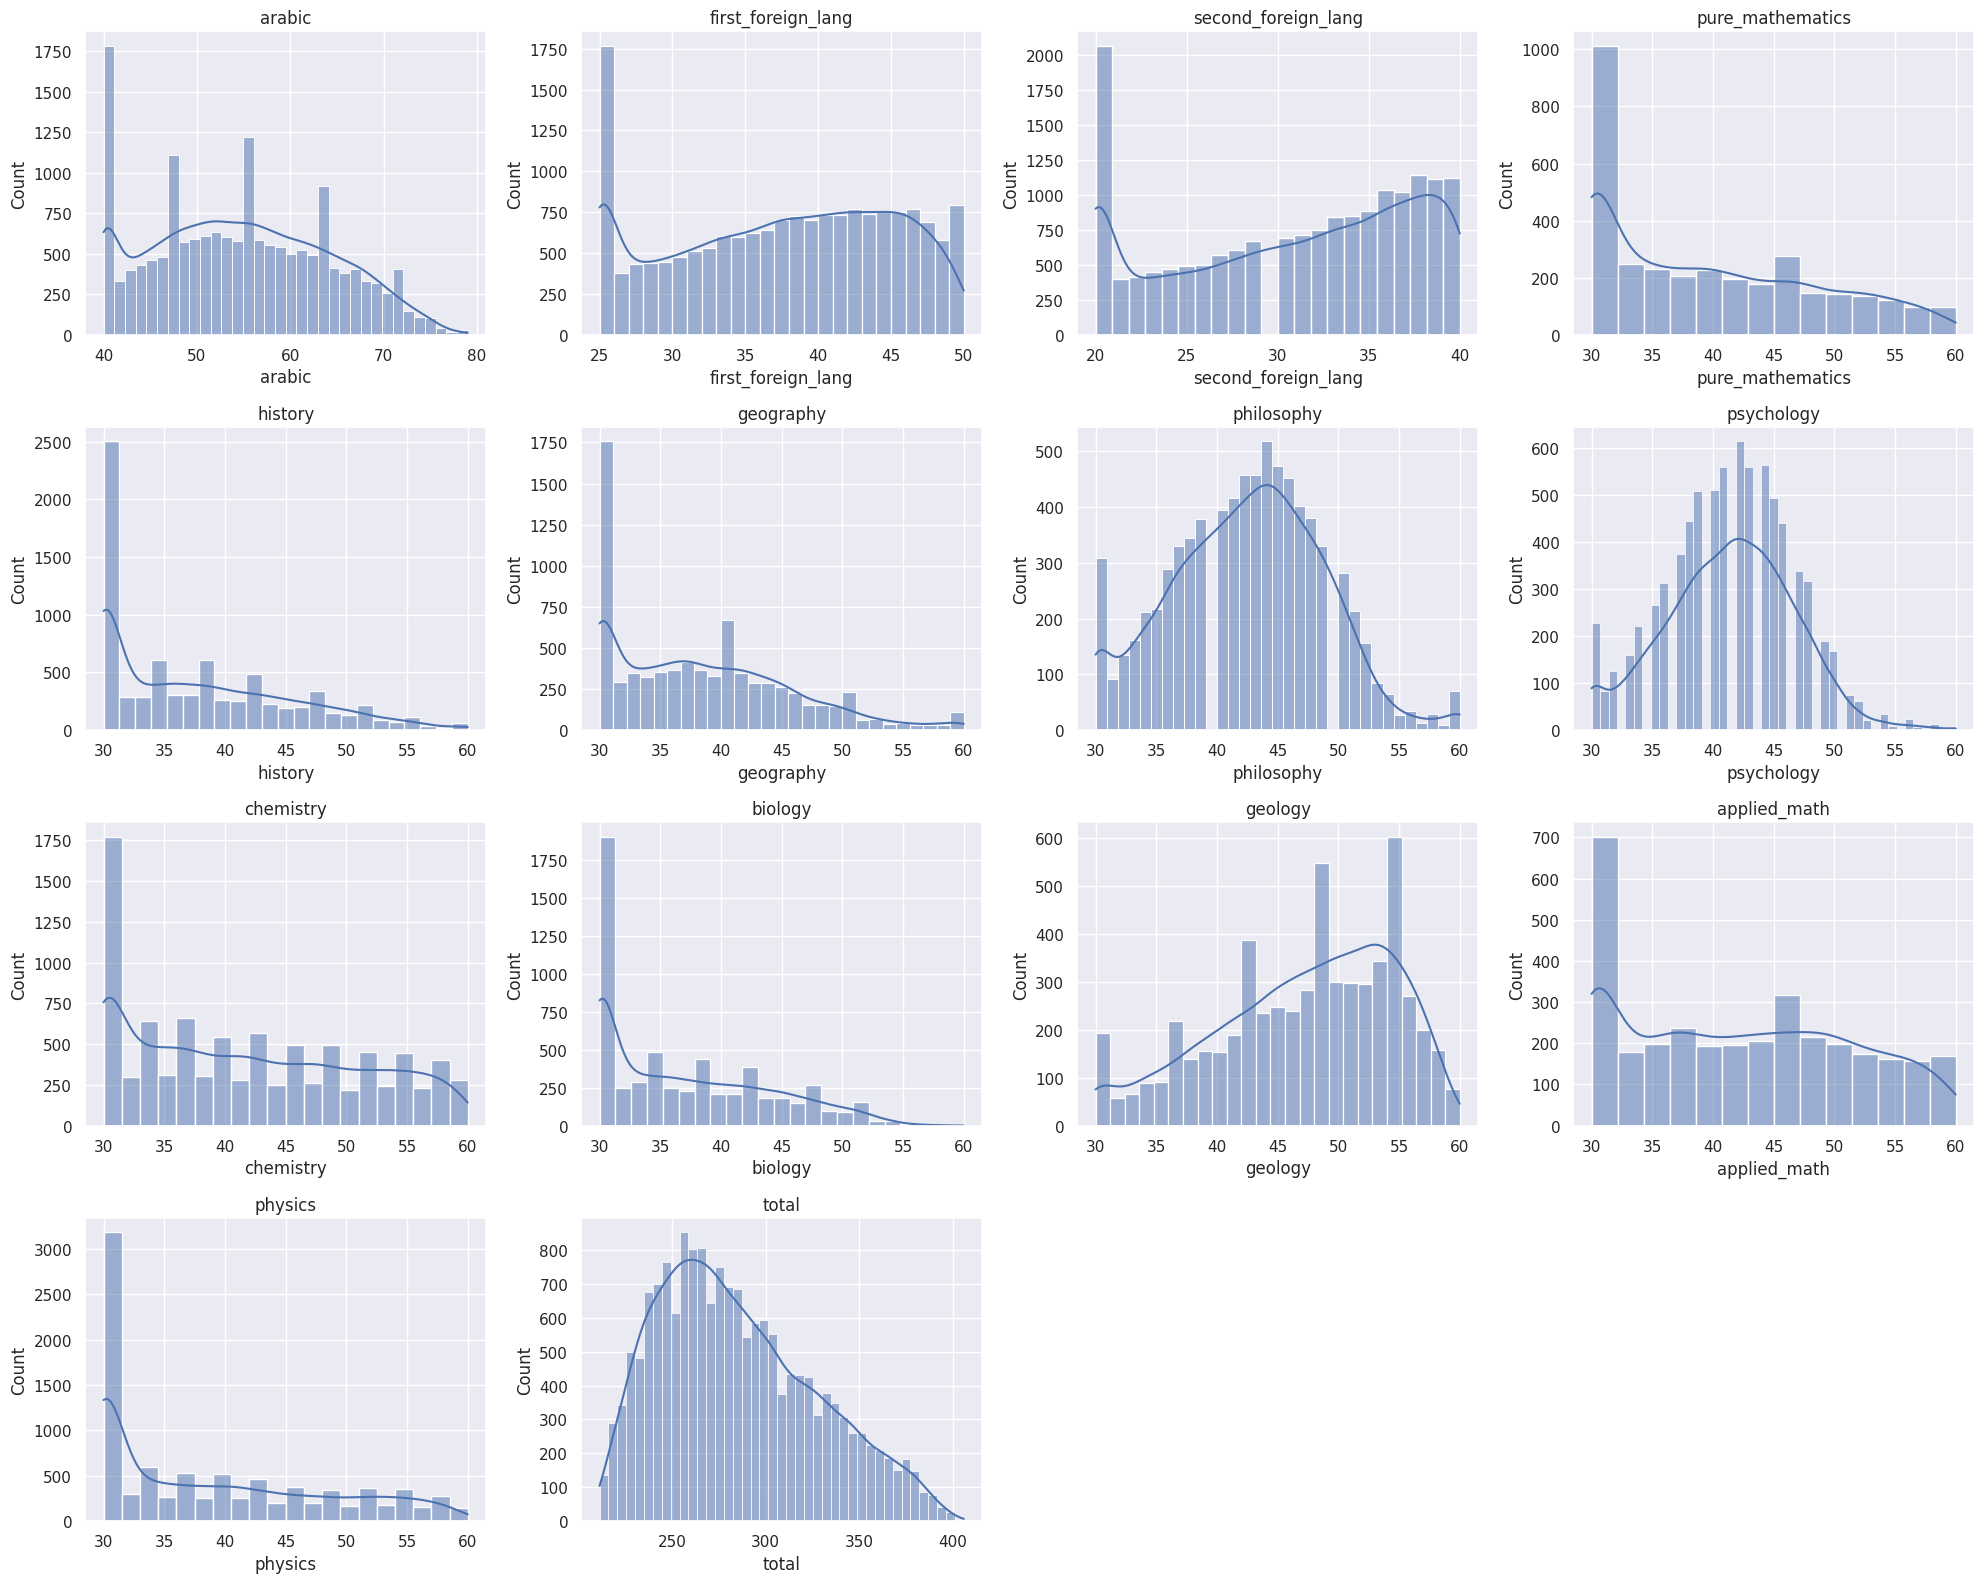

In [28]:
numerical_cols = data.select_dtypes(include=['number']).columns
num_rows = math.ceil(len(numerical_cols) / 4)
plt.figure(figsize=(20, 4 * num_rows))
for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, 4, i + 1)
    sns.histplot(data[col].dropna(), kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

### Boxplots — inspected, **not capped**

These box plots exist to *understand* the spread of each subject's grades, not to trigger clipping. A student scoring near the top or bottom of a subject's real range is exactly what a faculty-recommendation model needs to see — an unusually high Physics grade for a Science-track student is a genuine signal toward Engineering/Medicine, not measurement noise. IQR-capping such values would flatten the very distinctions the model is meant to learn, so we inspect only, and leave the values untouched.

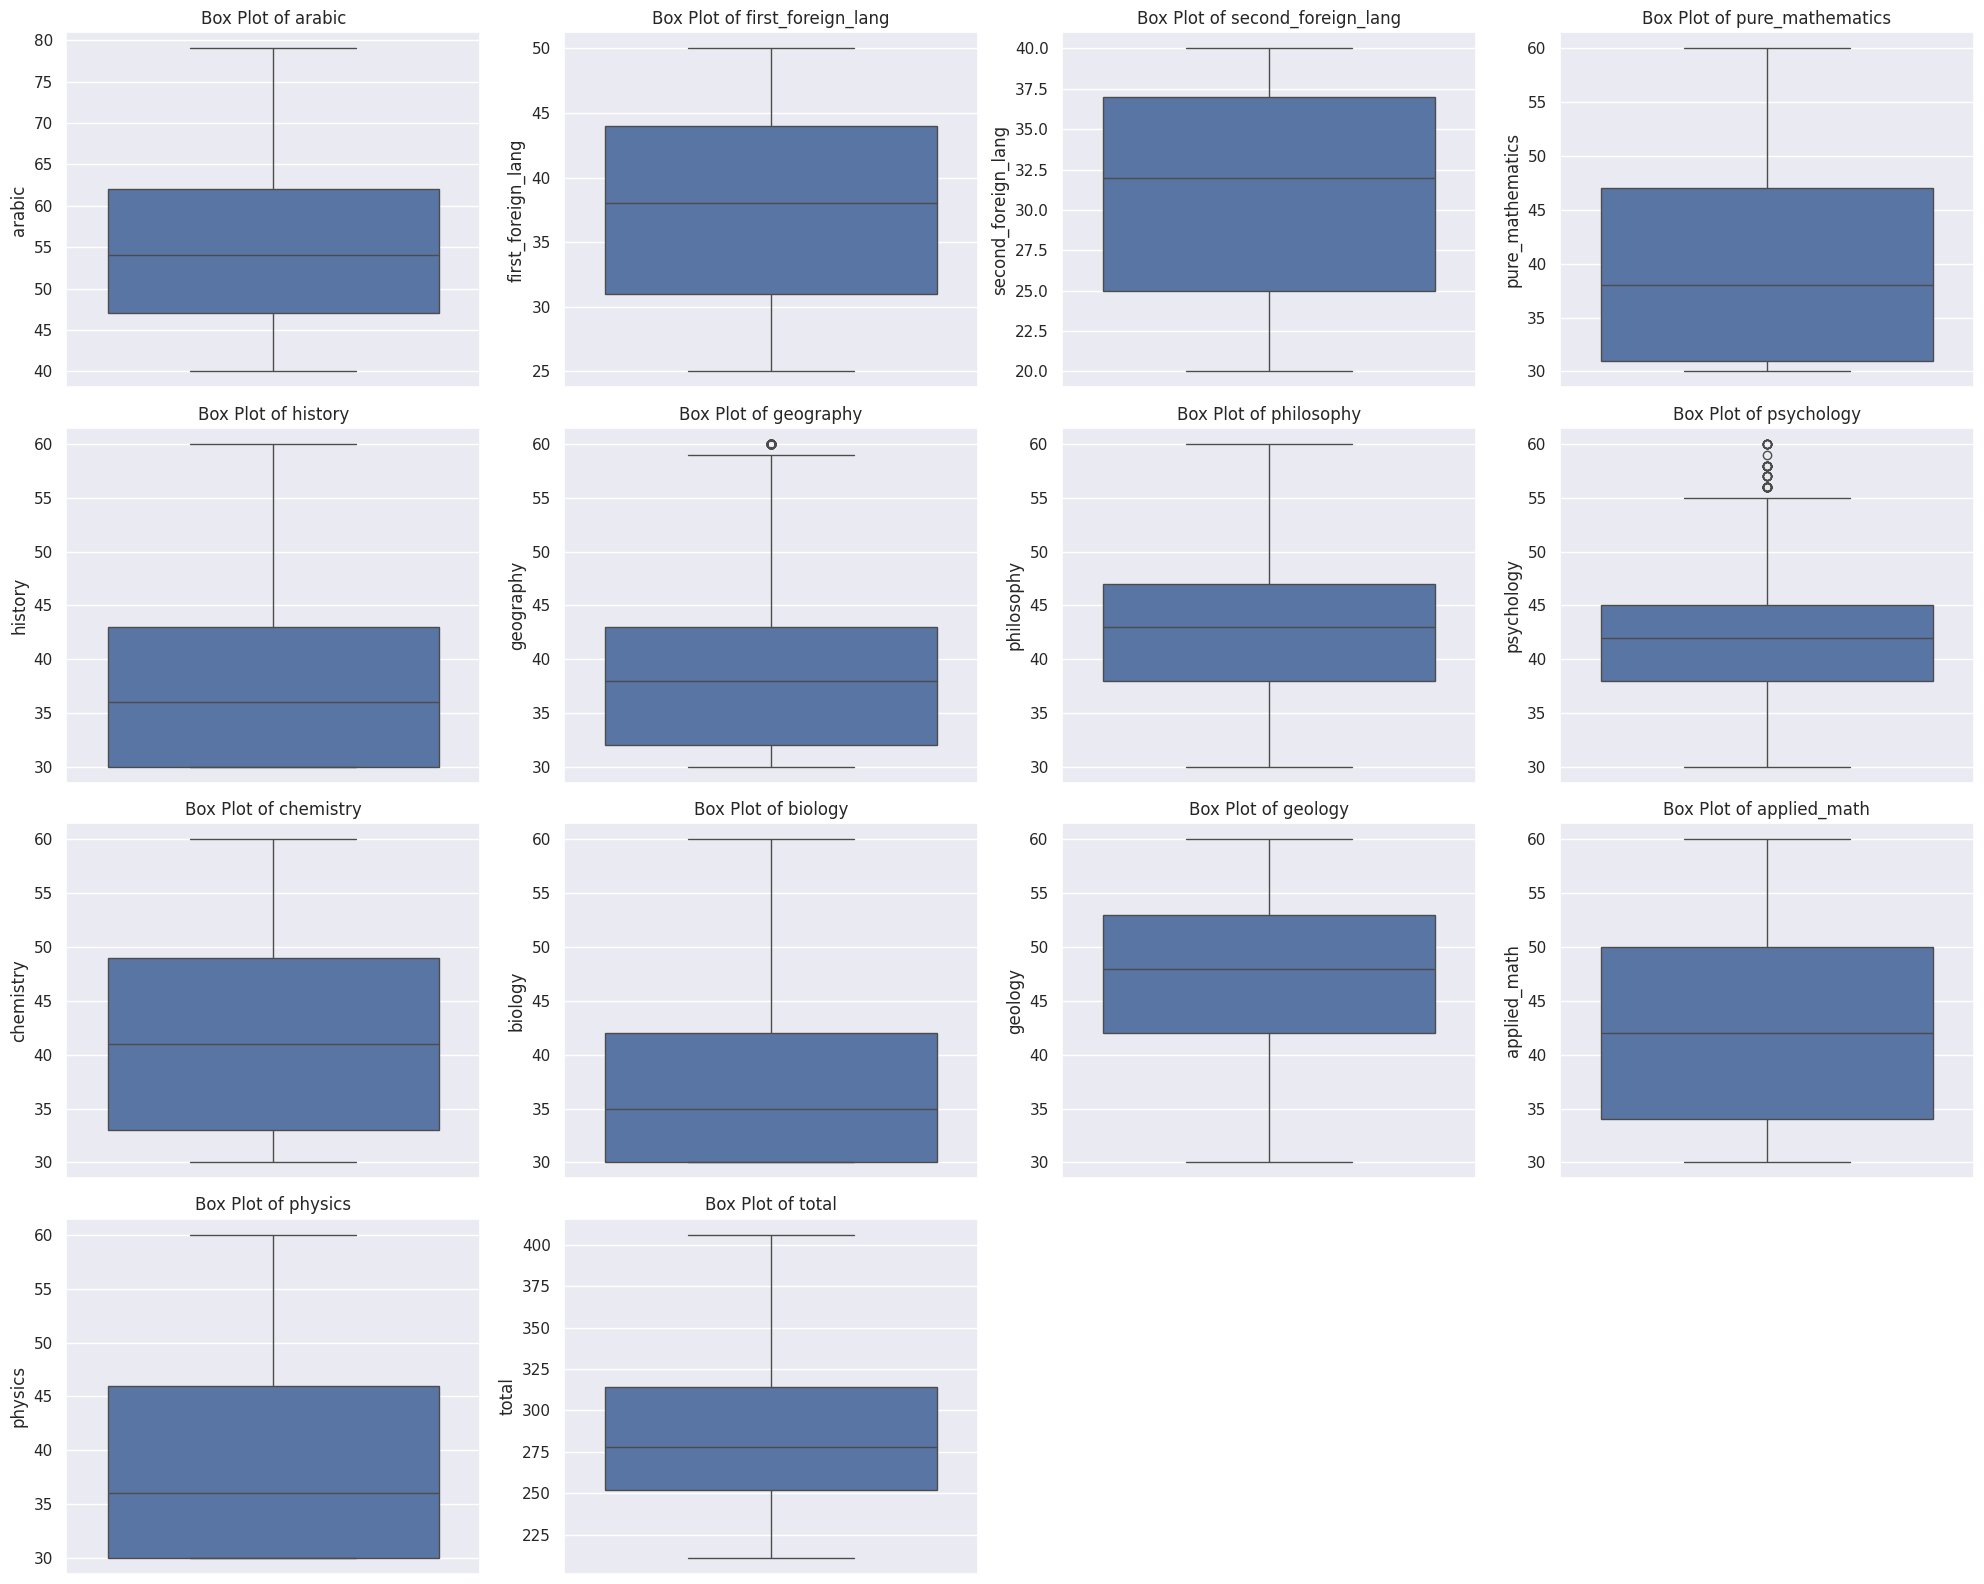

In [29]:
numerical_cols = data.select_dtypes(include=['number']).columns
num_rows = math.ceil(len(numerical_cols) / 4)
plt.figure(figsize=(20, 4 * num_rows))
for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, 4, i + 1)
    sns.boxplot(y=data[col].dropna())
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

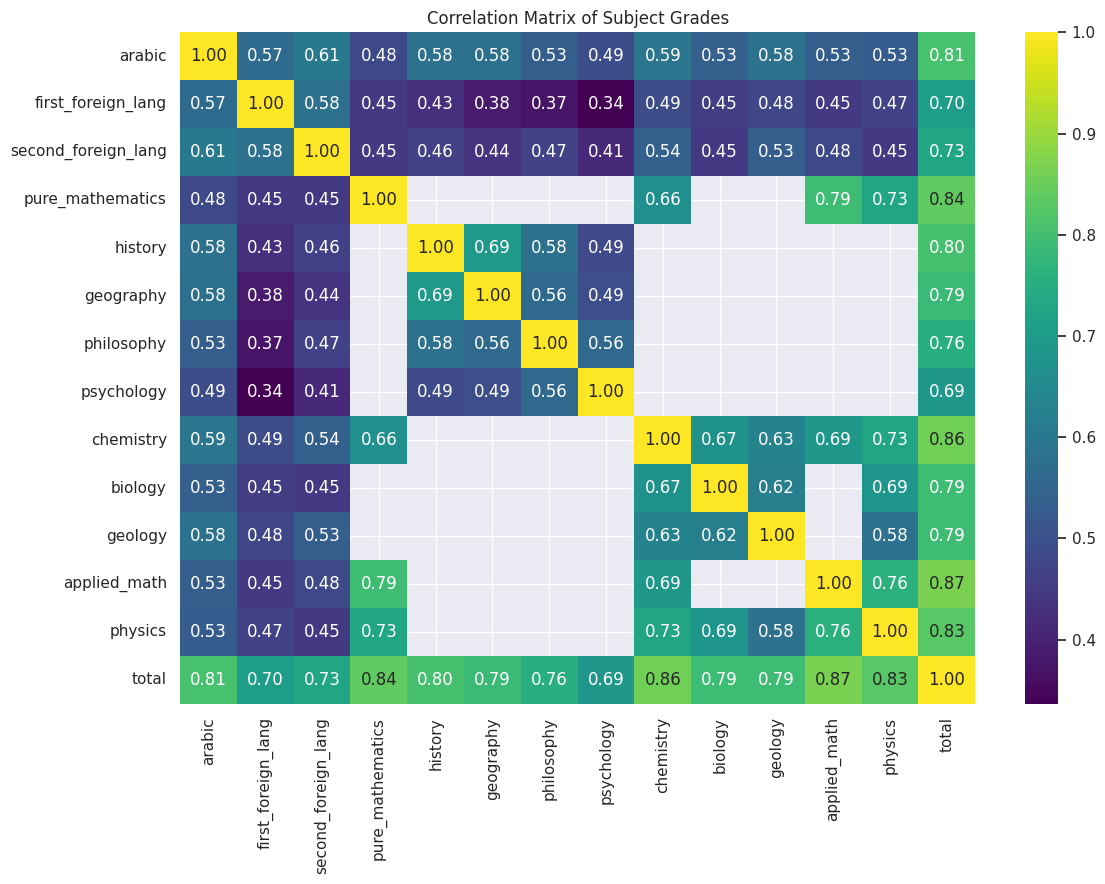

In [30]:
numerical_subject_cols = ['arabic', 'first_foreign_lang', 'second_foreign_lang',
                          'pure_mathematics', 'history', 'geography', 'philosophy', 'psychology',
                          'chemistry', 'biology', 'geology', 'applied_math', 'physics', 'total']
subject_data = data[numerical_subject_cols]
correlation_matrix = subject_data.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='viridis')
plt.title('Correlation Matrix of Subject Grades')
plt.tight_layout()
plt.show()

**Sanity check** — no negative marks, none exceeding the max possible per subject:

In [31]:
subjects = [
    'arabic', 'first_foreign_lang', 'second_foreign_lang', 'pure_mathematics',
    'history', 'geography', 'philosophy', 'psychology', 'chemistry',
    'biology', 'geology', 'applied_math', 'physics'
]
for col in subjects:
    print(f'{col:22s} min={data[col].min():>6}  max={data[col].max():>6}')

arabic                 min=  40.0  max=  79.0
first_foreign_lang     min=  25.0  max=  50.0
second_foreign_lang    min=  20.0  max=  40.0
pure_mathematics       min=  30.0  max=  60.0
history                min=  30.0  max=  60.0
geography              min=  30.0  max=  60.0
philosophy             min=  30.0  max=  60.0
psychology             min=  30.0  max=  60.0
chemistry              min=  30.0  max=  60.0
biology                min=  30.0  max=  60.0
geology                min=  30.0  max=  60.0
applied_math           min=  30.0  max=  60.0
physics                min=  30.0  max=  60.0


In [32]:
categorical_cols = ['Track', 'Faculty_Category']
for col in categorical_cols:
    print(f'\n{col}')
    print(data[col].value_counts())


Track
Track
Literacy    7730
Science     5837
Math        3305
Name: count, dtype: int64

Faculty_Category
Faculty_Category
Other                            2964
Education                        2754
Commerce                         1552
Law                              1402
Arts                             1290
Early Childhood Education        1064
Archaeology                       575
Agriculture                       555
Economics                         464
Science                           445
Languages (Al-Alsun)              391
Sports Education                  361
Medicine                          357
Nursing                           347
Engineering                       334
Tourism and Hotels                317
Medicine Veterinary               245
Mass Communication                208
Computers and Information         175
Social Service                    156
Dar Al-Uloom                      156
Technical Health Institute        129
Physical Therapy                   89
P

Null-value distribution across the dataset (confirms the pattern is structural / track-driven, not random):

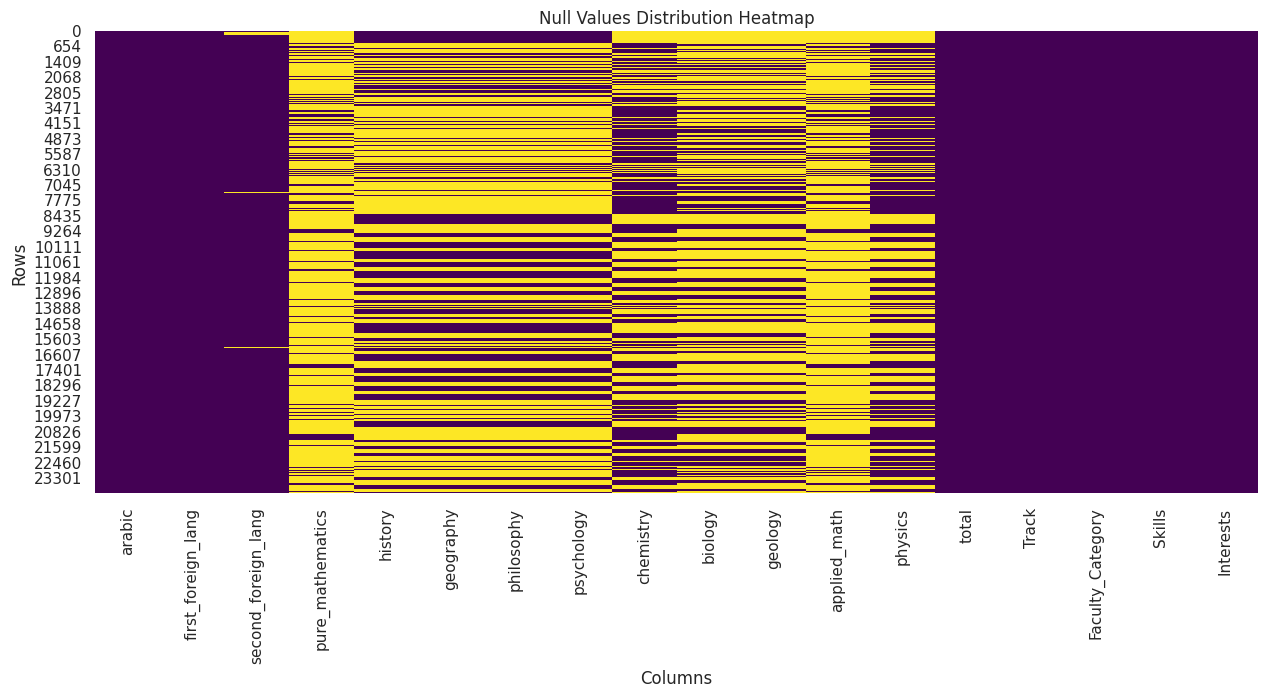

In [33]:
plt.figure(figsize=(15, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Null Values Distribution Heatmap')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

In [34]:
data[['total','Faculty_Category']].sample(10)

,total,Faculty_Category
21493,316.0,Archaeology
14355,289.0,Commerce
3416,398.0,Medicine
561,268.0,Early Childhood Education
14212,288.0,Early Childhood Education
9457,302.0,Education
22807,278.0,Commerce
15969,276.0,Education
17294,235.0,Other
3626,319.0,Aquaculture and Fisheries


In [35]:
pd.crosstab(
    data['Track'],
    data['Faculty_Category'],
    normalize='index'
)

Faculty_Category,Agriculture,Applied Health Technology,Aquaculture and Fisheries,Archaeology,Archaeology and Languages,Artificial Intelligence,Arts,Co,Commerce,Computers and Information,Dar Al-Uloom,Disability and Rehabilitation,Early Childhood Education,Economics,Education,Engineering,Information Systems,Languages (Al-Alsun),Law,Mass Communication,Medicine,Medicine Dentistry,Medicine Veterinary,Nursing,Other,Pharmacy,Physical Therapy,Science,Science Petroleum and Mining,Social Service,Sports Education,Technical Commercial,Technical Health Institute,Tourism and Hotels
Track,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Literacy,0.000000,0.000000,0.000000,0.040103,0.00414,0.000000,0.118499,0.000000,0.109056,0.000000,0.009702,0.002975,0.057697,0.057309,0.187710,0.000000,0.000000,0.037516,0.085770,0.018111,0.000000,0.000000,0.000000,0.000000,0.188357,0.000000,0.000000,0.000000,0.000000,0.020181,0.031177,0.010091,0.000000,0.021604
Math,0.059002,0.012708,0.000000,0.019970,0.00000,0.011195,0.032073,0.000303,0.070499,0.020575,0.009380,0.000000,0.053858,0.006354,0.138275,0.045083,0.000000,0.011498,0.086536,0.009077,0.051135,0.008775,0.036914,0.037519,0.164902,0.010287,0.013011,0.053253,0.001815,0.000000,0.005749,0.000000,0.014221,0.016036
Science,0.061676,0.004454,0.010451,0.034093,0.00000,0.000000,0.045914,0.000000,0.081549,0.018331,0.008566,0.006853,0.075381,0.000000,0.144937,0.031694,0.003769,0.010793,0.077608,0.006510,0.032208,0.005311,0.021072,0.038205,0.164982,0.008395,0.007881,0.046085,0.005311,0.000000,0.017303,0.000000,0.014048,0.016618


## Feature Engineering & Preprocessing Pipeline

**Approach:** `Track` structurally determines which subjects a student sat for (Math track sits `pure_mathematics`/`applied_math`, Science track sits `chemistry`/`biology`/`geology`/`physics`, Literacy track sits `history`/`geography`/`philosophy`/`psychology`). Everything below — imputing the structural nulls, building aggregate features, encoding `Skills`/`Interests`, the selective power-transform, scaling, and feature selection — is implemented as a chain of custom scikit-learn transformers, then combined into **one `Pipeline`**. That pipeline is:

- fit **once**, on the training split only (no leakage into the test set or into new-student inference),
- reusable as-is for scoring a brand-new student in the recommender at the end,
- and easy to swap the final classifier in/out when comparing models.

We deliberately picked *only* the steps that make sense for this data:
- **Structural 0-imputation** for subject columns — a null here always means "Track didn't include this subject", never "unknown grade", so `0` is a safe, unambiguous sentinel (every real grade starts well above 0).
- **Selective Yeo-Johnson** — applied only to the few columns that are actually skewed (checked programmatically), not blanket-applied to every numeric column.
- **Scaling** — doesn't help tree ensembles, but doesn't hurt them either, and is required for the `LogisticRegression` baseline we compare against, so it's applied once, centrally.
- **No outlier capping** — removed, per the note in the EDA section above.
- **Feature selection** (near-zero-variance drop → high-correlation drop → RandomForest-importance top-k) — needed because multi-hot encoding `Skills`/`Interests` creates a lot of sparse, low-signal columns; this keeps the model input compact.

In [36]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from collections import Counter

SCIENCE_COLS = ['chemistry', 'biology', 'geology', 'physics', 'pure_mathematics', 'applied_math']
HUMANITIES_COLS = ['history', 'geography', 'philosophy', 'psychology']
LANGUAGE_COLS = ['arabic', 'first_foreign_lang', 'second_foreign_lang']
SUBJECT_COLS = LANGUAGE_COLS + ['pure_mathematics', 'history', 'geography', 'philosophy',
                                 'psychology', 'chemistry', 'biology', 'geology', 'applied_math', 'physics']

**Step 1 — Structural imputation + engineered aggregates.** `total` is *recomputed* from the subject grades (rather than trusting the raw `total` column) so that training and single-student inference always go through the exact same formula.

In [37]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Structural imputation (subject not taken -> 0) + engineered aggregate features.
    Learns only the per-Track max total (needed for total_pct) from the training data."""

    def fit(self, X, y=None):
        X = X.copy()
        X[SUBJECT_COLS] = X[SUBJECT_COLS].fillna(0)
        total = X[SUBJECT_COLS].sum(axis=1)
        self.track_max_total_ = total.groupby(X['Track']).max().to_dict()
        self.global_max_total_ = total.max()
        return self

    def transform(self, X):
        X = X.copy()
        X[SUBJECT_COLS] = X[SUBJECT_COLS].fillna(0)
        X['total'] = X[SUBJECT_COLS].sum(axis=1)
        # X['num_subjects_taken'] = (X[SUBJECT_COLS] > 0).sum(axis=1)
        X['avg_subject_score'] = X[SUBJECT_COLS].replace(0, np.nan).mean(axis=1).fillna(0)
        track_max = X['Track'].map(self.track_max_total_).fillna(self.global_max_total_)
        X['total_pct'] = (X['total'] / track_max).clip(upper=1.0)
        X['science_score_avg'] = X[SCIENCE_COLS].replace(0, np.nan).mean(axis=1).fillna(0)
        X['humanities_score_avg'] = X[HUMANITIES_COLS].replace(0, np.nan).mean(axis=1).fillna(0)
        X['language_score_avg'] = X[LANGUAGE_COLS].replace(0, np.nan).mean(axis=1).fillna(0)
        return X

**Step 2 — `Skills` / `Interests` multi-hot encoding.** These are free-text, comma-separated, high-cardinality columns. Instead of one-hot encoding every unique *combination*, each entry is split into tokens and multi-hot encoded using only the **top-K most frequent tokens learned from the training set**, with a catch-all `Other` bucket for rare ones.

These transformers (`TopKMultiHotEncoder`, `TextToList`, `DropRawTextCols`) are **not** used in the classifier's own pipeline — the classifier is trained on subject grades / Track / totals only. They're reused later, via `build_profile_steps()`, purely for the recommender's content-based similarity score.

In [38]:
from sklearn.base import BaseEstimator, TransformerMixin
from collections import Counter
import pandas as pd

class TopKMultiHotEncoder(BaseEstimator, TransformerMixin):
    """Multi-hot encodes a free-text comma separated column using the top-K tokens
    learned from the training set only, with an 'Other' catch-all bucket."""

    def __init__(self, list_col, prefix, k=30):
        self.list_col = list_col
        self.prefix = prefix
        self.k = k

    def fit(self, X, y=None):
        counter = Counter()
        for lst in X[self.list_col]:
            counter.update(lst)
        self.vocab_ = [tok for tok, _ in counter.most_common(self.k)]
        return self

    def transform(self, X):
        X = X.copy()
        for tok in self.vocab_:
            col = f'{self.prefix}_{tok.replace(" ", "_")}'
            X[col] = X[self.list_col].apply(lambda lst: int(tok in lst))
        X[f'{self.prefix}_Other'] = X[self.list_col].apply(lambda lst: int(any(t not in self.vocab_ for t in lst)))
        return X


class DropRawTextCols(BaseEstimator, TransformerMixin):
    """Drops the intermediate free-text / list columns once they've been encoded."""
    def __init__(self, cols):
        self.cols = cols
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X.drop(columns=[c for c in self.cols if c in X.columns])


class TrackOneHotEncoder(BaseEstimator, TransformerMixin):
    """One-hot encodes the 3-category Track column."""
    def fit(self, X, y=None):
        self.categories_ = sorted(X['Track'].dropna().unique().tolist())
        return self
    def transform(self, X):
        X = X.copy()
        for cat in self.categories_:
            X[f'Track_{cat}'] = (X['Track'] == cat).astype(int)
        return X.drop(columns=['Track'])


class DropPrefixedCols(BaseEstimator, TransformerMixin):
    """Drops any column whose name starts with one of the given prefixes.
    Used to keep skill_/interest_ multi-hot columns OUT of the classifier's
    feature selection + model training, while a separate, earlier pipeline
    (used only for the recommender's content-based similarity) still keeps
    them."""
    def __init__(self, prefixes):
        self.prefixes = prefixes
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        cols_to_drop = [c for c in X.columns if any(c.startswith(p) for p in self.prefixes)]
        return X.drop(columns=cols_to_drop)

# NEW CLASS TO ADD
class TextToList(BaseEstimator, TransformerMixin):
    """Converts a comma-separated string column into a list of strings."""
    def __init__(self, cols):
        self.cols = cols
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_copy = X.copy()
        for col in self.cols:
            # Ensure handling of NaN values or non-string types gracefully
            X_copy[col] = X_copy[col].apply(
                lambda x: [item.strip() for item in str(x).split(',') if item.strip()] if pd.notna(x) else []
            )
        return X_copy

class DropSpecificCols(BaseEstimator, TransformerMixin):
    """Drops a list of specified columns."""
    def __init__(self, cols):
        self.cols = cols
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X.drop(columns=[c for c in self.cols if c in X.columns])

**Step 3 — Selective Yeo-Johnson.** Only columns with `|skew| > 0.75` on the (capped-free) training data are transformed — most subject scores are already close to symmetric, so most columns pass through untouched. Yeo-Johnson (not Box-Cox) because it handles the `0` sentinel safely.

In [39]:
class SelectiveYeoJohnson(BaseEstimator, TransformerMixin):
    """Applies Yeo-Johnson only to numeric columns whose |skew| > threshold on the
    training data."""
    def __init__(self, cols, skew_threshold=0.75):
        self.cols = cols
        self.skew_threshold = skew_threshold
    def fit(self, X, y=None):
        self.skewed_cols_ = [c for c in self.cols if abs(X[c].skew()) > self.skew_threshold]
        if self.skewed_cols_:
            self.pt_ = PowerTransformer(method='yeo-johnson')
            self.pt_.fit(X[self.skewed_cols_])
        else:
            self.pt_ = None
        return self
    def transform(self, X):
        X = X.copy()
        if self.skewed_cols_:
            X[self.skewed_cols_] = self.pt_.transform(X[self.skewed_cols_])
        return X


class SelectiveScaler(BaseEstimator, TransformerMixin):
    """StandardScaler applied only to the numeric feature columns."""
    def __init__(self, cols):
        self.cols = cols
    def fit(self, X, y=None):
        self.scaler_ = StandardScaler()
        self.scaler_.fit(X[self.cols])
        return self
    def transform(self, X):
        X = X.copy()
        X[self.cols] = self.scaler_.transform(X[self.cols])
        return X

**Step 4 — Feature selection**, three passes, all fit on the training split only: drop near-zero-variance columns, drop one of each highly-correlated pair (`|corr| > 0.90`) — this matters here, since `total`, `avg_subject_score`, and `total_pct` are near-duplicates of each other by construction — then rank the rest by `RandomForestClassifier` importance and keep the top-K.

In [40]:
class DropNearZeroVariance(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.001):
        self.threshold = threshold
    def fit(self, X, y=None):
        vt = VarianceThreshold(threshold=self.threshold)
        vt.fit(X)
        self.kept_cols_ = X.columns[vt.get_support()].tolist()
        self.dropped_cols_ = X.columns[~vt.get_support()].tolist()
        return self
    def transform(self, X):
        return X[self.kept_cols_]


class DropCorrelated(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.90):
        self.threshold = threshold
    def fit(self, X, y=None):
        corr = X.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        self.to_drop_ = [c for c in upper.columns if any(upper[c] > self.threshold)]
        return self
    def transform(self, X):
        return X.drop(columns=self.to_drop_)


class SelectTopKImportance(BaseEstimator, TransformerMixin):
    """Ranks features by RandomForest importance (fit on the training fold only) and
    keeps the top-k. Kept small/regularized so it stays memory-safe on large datasets."""
    def __init__(self, k=40, n_estimators=150, max_depth=20, min_samples_leaf=10, random_state=42):
        self.k = k
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        rf = RandomForestClassifier(n_estimators=self.n_estimators, max_depth=self.max_depth,
                                     min_samples_leaf=self.min_samples_leaf, max_features='sqrt',
                                     random_state=self.random_state, n_jobs=-1, class_weight='balanced')
        rf.fit(X, y, sample_weight=sample_weight)
        importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
        self.selected_features_ = importances.head(min(self.k, len(importances))).index.tolist()
        self.importances_ = importances
        return self

    def transform(self, X):
        return X[self.selected_features_]

### Handling Rare Classes

The target variable contained several faculty categories with very few samples (fewer than **50** instances). Such rare classes provide insufficient training examples for the model, making it difficult to learn meaningful patterns and often leading to poor prediction performance for those categories.

To improve the model's robustness and reduce the impact of severe class imbalance, these infrequent categories were grouped into a single **"Other"** class. This approach simplifies the classification task, improves class representation, and enhances the model's ability to generalize while maintaining meaningful predictions.

In [41]:
counts = data["Faculty_Category"].value_counts()

rare_classes = counts[counts < 50].index

data["Faculty_Category"] = data["Faculty_Category"].replace(
    rare_classes,
    "Other"
)

In [42]:
data['Faculty_Category'].value_counts()

,count
Faculty_Category,
Other,3093
Education,2754
Commerce,1552
Law,1402
Arts,1290
Early Childhood Education,1064
Archaeology,575
Agriculture,555
Economics,464


## Split Data

We split *before* fitting any transformer (they're all fit inside the pipeline, on the training fold only) to avoid leakage. Stratified on `Faculty_Category` since the target is strongly imbalanced.

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

feature_cols_raw = SUBJECT_COLS + ['Track', 'total']
target_col = 'Faculty_Category'

# Drop rows where the target column is NaN or None to prevent TypeError during stratification
data_cleaned = data.dropna(subset=[target_col]).copy()

X = data_cleaned[feature_cols_raw].copy()
y = data_cleaned[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

label_enc = LabelEncoder()
y_train_enc = label_enc.fit_transform(y_train)
y_test_enc = label_enc.transform(y_test)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)

Train shape: (13497, 15)  Test shape: (3375, 15)


In [44]:
numeric_cols_for_transform = SUBJECT_COLS + ['total', 'avg_subject_score', 'science_score_avg',
                                              'humanities_score_avg', 'language_score_avg']
scale_cols = numeric_cols_for_transform + ['total_pct']
.

def build_shared_steps():
    """Steps shared by BOTH the classifier pipeline and the recommender's
    content-profile pipeline: structural imputation/engineering, and the
    Track one-hot. Fresh instances each time so every consumer gets its own
    independently-fit copy."""
    return [
        ('feature_engineer', FeatureEngineer()),
        ('track_ohe', TrackOneHotEncoder()),
    ]

def build_preprocessing_steps():
    """Full CLASSIFIER preprocessing pipeline.

    Skills/Interests are deliberately excluded from the classifier -- they're
    only used in the recommender's content-based similarity via
    build_profile_steps() (see the Recommendation System section below).
    `drop_skill_interest` is a defensive no-op here since X_train never
    contains those raw columns to begin with.

    Feature selection is three passes, all fit on the training fold only:
    drop near-zero-variance columns, drop one of each highly-correlated pair
    (|corr| > 0.90), then rank the rest by RandomForest importance and keep
    the top-K.
    """
    return build_shared_steps() + [
        ('drop_skill_interest', DropPrefixedCols(['skill_', 'interest_'])),
        ('yeo_johnson', SelectiveYeoJohnson(numeric_cols_for_transform)),
        # ('scaler', SelectiveScaler(scale_cols)),
        ('drop_low_var', DropNearZeroVariance(threshold=0.001)),

    ]

print('Preprocessing pipeline has', len(build_preprocessing_steps()), 'steps.')

Preprocessing pipeline has 5 steps.


###    **Model and Evaluation**


Models Evaluated and excluded from the notebook:
# **Logistic Regression:**
1. Not fitted to our problem because It assumes a linear decision boundary
2. Too many classes:
Logistic Regression supports multiclass classification (One-vs-Rest or Multinomial), but as the number of classes increases and boundaries become more complex, performance often decreases.
3. Feature interactions:Logistic Regression treats features mostly independently

# KNN:
1. Overfitting and can't generalize well on unseen data
2. Sensitive to irrelevant features

## Support Vector Machine (SVM):
1. SVM works best on small to medium datasets.
2. For multiclass problems, it builds many binary classifiers using strategies like One-vs-One or One-vs-Rest.
3. With many faculty categories, training and prediction become more complex and slower.

# Random Forest (Baseline)
Ensemble learning algorithm, which means it combines the predictions of many Decision Trees instead of relying on just one.
1. Handles complex relationships
2. Feature Importance
3. Suitable for large datasets

Pipeline for the preprocessing steps and the model

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(build_preprocessing_steps() + [
    ('classifier', RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=5, random_state=42, n_jobs=-1, class_weight='balanced'))
])

rf_pipeline.fit(X_train, y_train_enc)

print("Random Forest pipeline trained successfully!")

Random Forest pipeline trained successfully!


Cross validation was done to ensure model stability and reliabilty

In [46]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train_enc,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Scores:", scores)
print("Mean F1:", np.mean(scores))
print("Std:", np.std(scores))

Scores: [0.86171934 0.86083882 0.87183008 0.860385   0.86719484]
Mean F1: 0.8643936157757155
Std: 0.004449834991292137


In [47]:
y_pred_rf = rf_pipeline.predict(X_test)
print("Predictions for the test set have been made.")

Predictions for the test set have been made.


In [48]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_rf = accuracy_score(y_test_enc, y_pred_rf)
print(f'Random Forest Test Accuracy: {accuracy_rf:.4f}')

Random Forest Test Accuracy: 0.8984


In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test_enc, y_pred_rf))
print(
    "Precision:",
    precision_score(
        y_test_enc,
        y_pred_rf,
        average="weighted"
    )
)
print(
    "Recall:",
    recall_score(
        y_test_enc,
        y_pred_rf,
        average="weighted"
    )
)
print(
    "F1-score:",
    f1_score(
        y_test_enc,
        y_pred_rf,
        average="weighted"
    )
)

Accuracy : 0.8983703703703704
Precision: 0.9141117993977625
Recall: 0.8983703703703704
F1-score: 0.9009451373182834


In [50]:
print("Random Forest Classification Report:")
print(classification_report(y_test_enc, y_pred_rf, target_names=label_enc.classes_, zero_division=0))

Random Forest Classification Report:
                               precision    recall  f1-score   support

                  Agriculture       0.68      0.94      0.79       111
    Applied Health Technology       0.58      1.00      0.74        14
    Aquaculture and Fisheries       1.00      1.00      1.00        12
                  Archaeology       0.81      0.92      0.86       115
                         Arts       0.87      0.93      0.90       258
                     Commerce       0.93      0.90      0.92       310
    Computers and Information       0.65      0.91      0.76        35
                 Dar Al-Uloom       1.00      0.94      0.97        31
Disability and Rehabilitation       1.00      1.00      1.00        13
    Early Childhood Education       0.89      0.98      0.93       213
                    Economics       0.97      1.00      0.98        93
                    Education       0.97      0.80      0.88       551
                  Engineering       0.8

Evaluating Model accuracy on both Training and Testing to check if there is overfitting

In [51]:
y_pred_rf_train = rf_pipeline.predict(X_train)
accuracy_rf_train = accuracy_score(y_train_enc, y_pred_rf_train)

print(f'Random Forest Training Accuracy: {accuracy_rf_train:.4f}')
print(f'Random Forest Test Accuracy: {accuracy_rf:.4f}')

if accuracy_rf_train > accuracy_rf + 0.05:
    print("\nPotential overfitting detected: Training accuracy is significantly higher than test accuracy.")
elif accuracy_rf_train < accuracy_rf - 0.05:
    print("\nPotential underfitting detected: Training accuracy is significantly lower than test accuracy (uncommon for tree-based models).")
else:
    print("\nTraining and test accuracies are reasonably close, suggesting a good fit.")

Random Forest Training Accuracy: 0.9541
Random Forest Test Accuracy: 0.8984

Potential overfitting detected: Training accuracy is significantly higher than test accuracy.


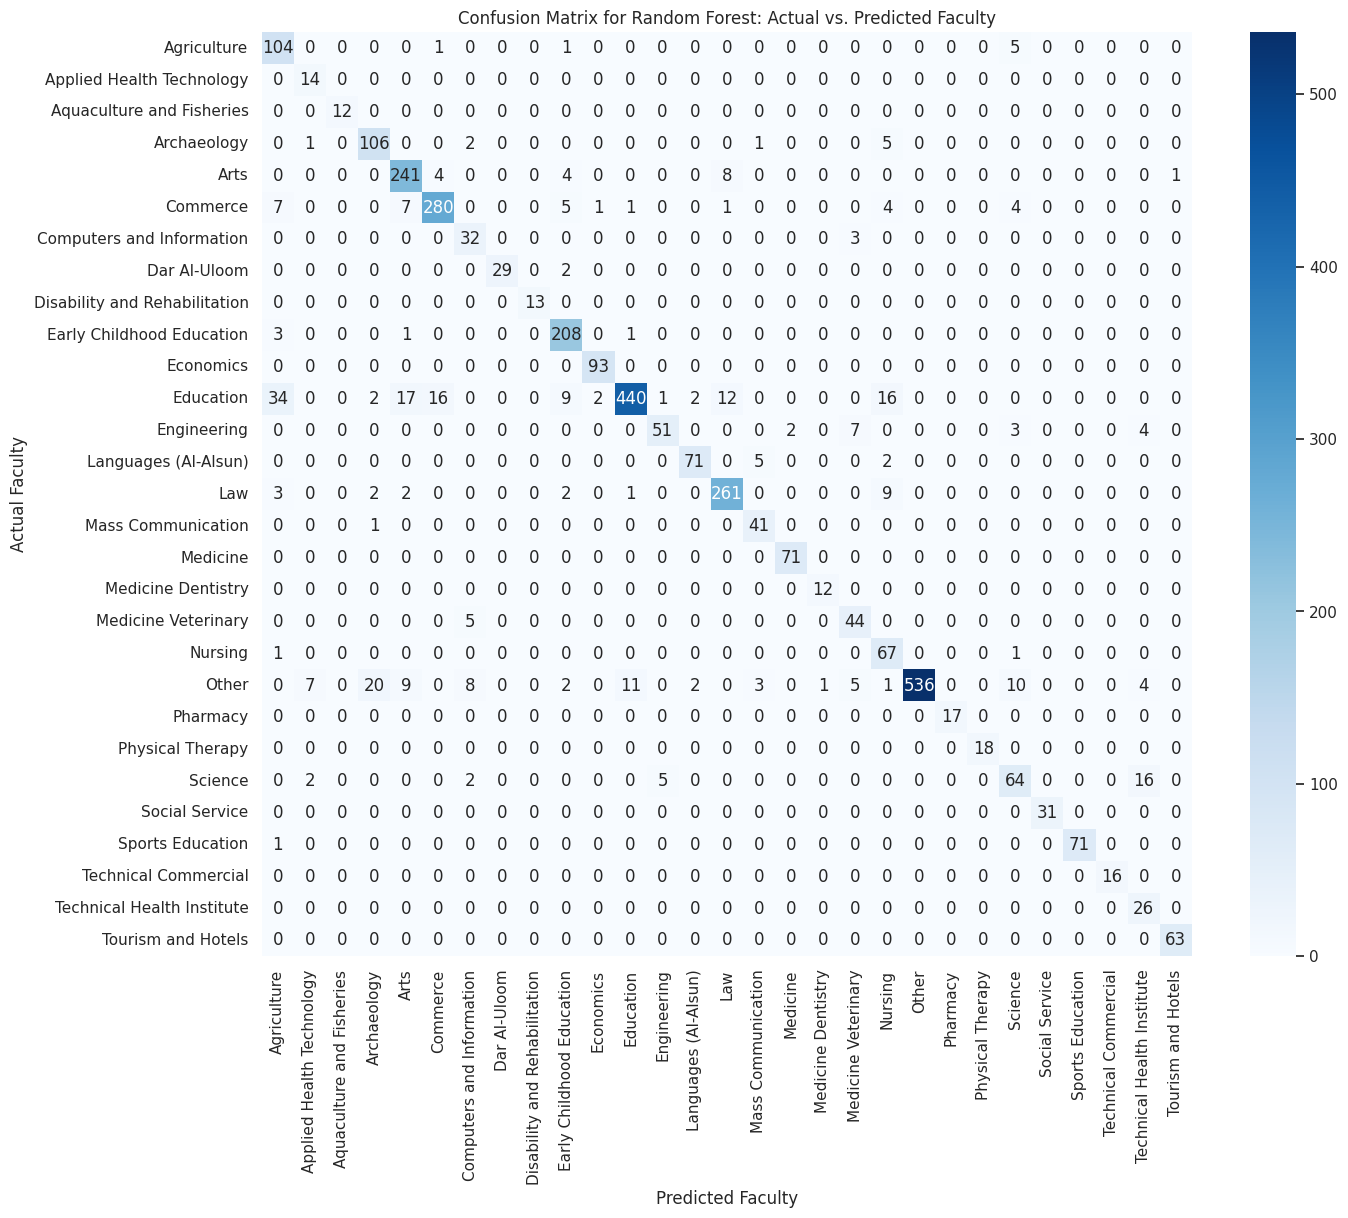

In [52]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_rf = confusion_matrix(y_test_enc, y_pred_rf)

plt.figure(figsize=(15, 12))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=label_enc.classes_, yticklabels=label_enc.classes_)
plt.xlabel('Predicted Faculty')
plt.ylabel('Actual Faculty')
plt.title('Confusion Matrix for Random Forest: Actual vs. Predicted Faculty')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

The number of correctly predicted instances for each faculty from the confusion matrix. (from the test set)

In [53]:
correct_predictions_rf = cm_rf.diagonal()
class_labels = label_enc.classes_

print("Correctly Predicted vs. Actual for Random Forest (from Confusion Matrix):")
for i, label in enumerate(class_labels):
    # The total actual instances for each class can be found from the 'support' in the classification report,
    # or by summing the corresponding row in the confusion matrix.
    total_actual = cm_rf.sum(axis=1)[i]
    print(f"  {label:30}: Correctly Predicted = {correct_predictions_rf[i]:<5} (Total Actual = {total_actual})")


Correctly Predicted vs. Actual for Random Forest (from Confusion Matrix):
  Agriculture                   : Correctly Predicted = 104   (Total Actual = 111)
  Applied Health Technology     : Correctly Predicted = 14    (Total Actual = 14)
  Aquaculture and Fisheries     : Correctly Predicted = 12    (Total Actual = 12)
  Archaeology                   : Correctly Predicted = 106   (Total Actual = 115)
  Arts                          : Correctly Predicted = 241   (Total Actual = 258)
  Commerce                      : Correctly Predicted = 280   (Total Actual = 310)
  Computers and Information     : Correctly Predicted = 32    (Total Actual = 35)
  Dar Al-Uloom                  : Correctly Predicted = 29    (Total Actual = 31)
  Disability and Rehabilitation : Correctly Predicted = 13    (Total Actual = 13)
  Early Childhood Education     : Correctly Predicted = 208   (Total Actual = 213)
  Economics                     : Correctly Predicted = 93    (Total Actual = 93)
  Education        

**Visualizing the important features extracted from Random Forest**

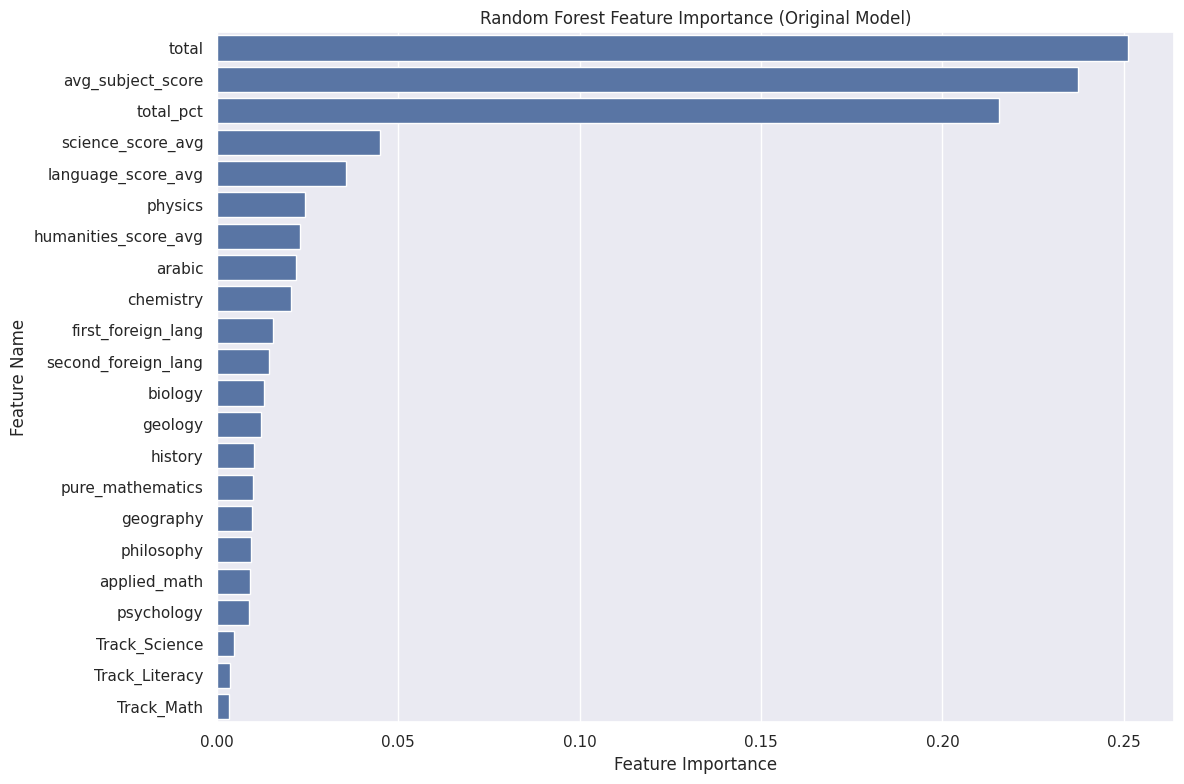

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get the Random Forest classifier from the original rf_pipeline
rf_classifier = rf_pipeline.named_steps['classifier']

# Get feature names from the already processed training data
X_processed = rf_pipeline[:-1].fit_transform(X_train, y_train_enc)
feature_names_for_importance = X_processed.columns.tolist()

# Get feature importances
importances = rf_classifier.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names_for_importance,
    'Importance': importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Random Forest Feature Importance (Original Model)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

# hyperParameter Tuning using RandomizedSearchCV

In [56]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    "classifier__n_estimators": randint(300, 600),
    "classifier__max_depth": [10,12, 15, 20],
    "classifier__min_samples_split": randint(5, 20),
    "classifier__min_samples_leaf": randint(4, 10),
    "classifier__max_features": ["sqrt"],
    "classifier__class_weight": ["balanced", "balanced_subsample"]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train_enc)

print("Best parameters:")
print(random_search.best_params_)

print("\nBest CV score:")
print(random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters:
{'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 7, 'classifier__n_estimators': 434}

Best CV score:
0.8917404068179243


In [57]:
best_rf = random_search.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score, f1_score

print("Test accuracy:", accuracy_score(y_test_enc, y_pred_rf_tuned))
print(
    "Test F1:",
    f1_score(
        y_test_enc,
        y_pred_rf_tuned,
        average="weighted"
    )
)

Test accuracy: 0.917037037037037
Test F1: 0.9189836144188559


In [58]:
print("Train score:", random_search.best_estimator_.score(X_train, y_train_enc))
print("Test score:", random_search.best_estimator_.score(X_test, y_test_enc))

Train score: 0.9747351263243684
Test score: 0.917037037037037


In [59]:
cv_results = random_search.cv_results_

for mean_score, params in zip(
    cv_results["mean_test_score"],
    cv_results["params"]
):
    print(round(mean_score, 4), params)

0.8101 {'classifier__class_weight': 'balanced', 'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 8, 'classifier__min_samples_split': 19, 'classifier__n_estimators': 406}
0.6339 {'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 8, 'classifier__min_samples_split': 11, 'classifier__n_estimators': 421}
0.8119 {'classifier__class_weight': 'balanced', 'classifier__max_depth': 15, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 6, 'classifier__min_samples_split': 15, 'classifier__n_estimators': 387}
0.8517 {'classifier__class_weight': 'balanced', 'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 6, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 557}
0.8023 {'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': 20, 'classifier__max_features': 'sq

**Hyperparameter Comparison for Random Forest Models**

In [60]:
print("Hyperparameter Comparison for Random Forest Models:")

# Get hyperparameters for the original Random Forest
rf_params = rf_pipeline.named_steps['classifier'].get_params()

# Get hyperparameters for the hypertuned Random Forest
rf_tuned_params = best_rf.named_steps['classifier'].get_params()

# Create a DataFrame for comparison
comparison_data = {
    'Hyperparameter': [],
    'Random Forest (Original)': [],
    'Random Forest (Hypertuned)': []
}

# List of hyperparameters to compare
hyperparams_to_compare = [
    'n_estimators', 'max_depth', 'min_samples_split',
    'min_samples_leaf', 'max_features', 'class_weight'
]

for param in hyperparams_to_compare:
    comparison_data['Hyperparameter'].append(param)
    comparison_data['Random Forest (Original)'].append(rf_params.get(param))
    comparison_data['Random Forest (Hypertuned)'].append(rf_tuned_params.get(param))

comparison_df_hyperparams = pd.DataFrame(comparison_data)

print(comparison_df_hyperparams.to_markdown(index=False))

Hyperparameter Comparison for Random Forest Models:
| Hyperparameter    | Random Forest (Original)   | Random Forest (Hypertuned)   |
|:------------------|:---------------------------|:-----------------------------|
| n_estimators      | 200                        | 434                          |
| max_depth         | 20                         | 20                           |
| min_samples_split | 2                          | 7                            |
| min_samples_leaf  | 5                          | 4                            |
| max_features      | sqrt                       | sqrt                         |
| class_weight      | balanced                   | balanced_subsample           |


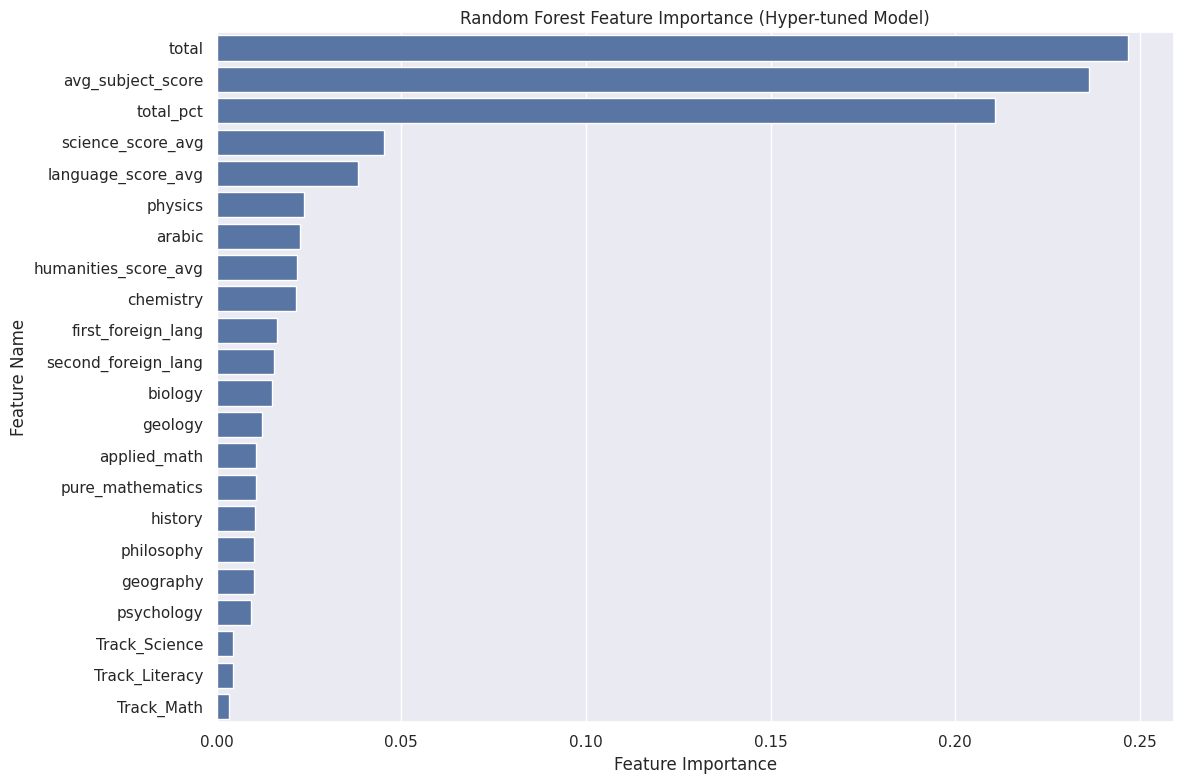

In [61]:
# Get the Random Forest classifier from the best_rf pipeline
rf_tuned_classifier = best_rf.named_steps['classifier']


# Get feature importances
importances_tuned = rf_tuned_classifier.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df_tuned = pd.DataFrame({
    'Feature': feature_names_for_importance,
    'Importance': importances_tuned
})

# Sort by importance
feature_importance_df_tuned = feature_importance_df_tuned.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_tuned)
plt.title('Random Forest Feature Importance (Hyper-tuned Model)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

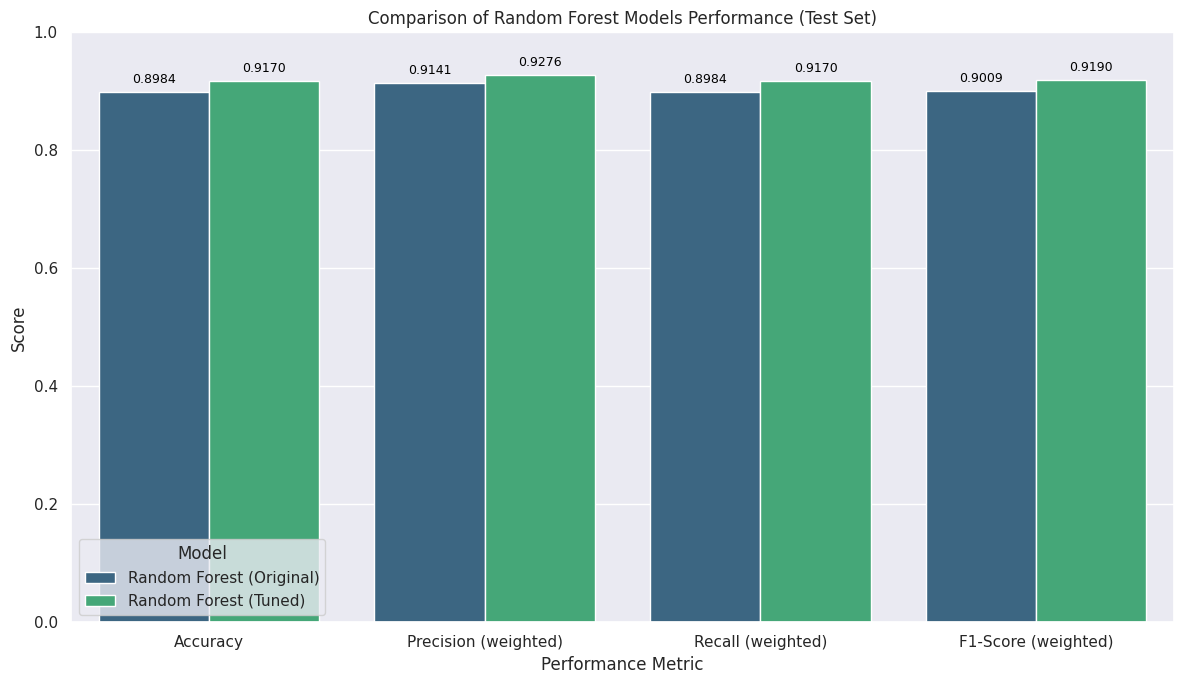

In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics for the original Random Forest model
accuracy_rf_orig = accuracy_score(y_test_enc, y_pred_rf)
precision_rf_orig = precision_score(y_test_enc, y_pred_rf, average='weighted', zero_division=0)
recall_rf_orig = recall_score(y_test_enc, y_pred_rf, average='weighted', zero_division=0)
f1_rf_orig = f1_score(y_test_enc, y_pred_rf, average='weighted', zero_division=0)

# Calculate metrics for the hyper-tuned Random Forest model
accuracy_rf_tuned = accuracy_score(y_test_enc, y_pred_rf_tuned)
precision_rf_tuned = precision_score(y_test_enc, y_pred_rf_tuned, average='weighted', zero_division=0)
recall_rf_tuned = recall_score(y_test_enc, y_pred_rf_tuned, average='weighted', zero_division=0)
f1_rf_tuned = f1_score(y_test_enc, y_pred_rf_tuned, average='weighted', zero_division=0)

# Create a DataFrame for comparison
comparison_data = {
    'Metric': ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1-Score (weighted)'],
    'Random Forest (Original)': [accuracy_rf_orig, precision_rf_orig, recall_rf_orig, f1_rf_orig],
    'Random Forest (Tuned)': [accuracy_rf_tuned, precision_rf_tuned, recall_rf_tuned, f1_rf_tuned]
}
comparison_df = pd.DataFrame(comparison_data)

# Melt the DataFrame for easier plotting with seaborn
comparison_melted = comparison_df.melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=comparison_melted, palette='viridis')
plt.title('Comparison of Random Forest Models Performance (Test Set)')
plt.xlabel('Performance Metric')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are typically between 0 and 1

for index, row in comparison_melted.iterrows():
    plt.text(x=index % len(comparison_df['Metric'].unique()) - 0.2 + (index // len(comparison_df['Metric'].unique())) * 0.4,
             y=row['Score'] + 0.01,
             s=f"{row['Score']:.4f}",
             color='black', ha='center', va='bottom', fontsize=9)

plt.legend(title='Model')
plt.tight_layout()
plt.show()

### CatBoost

In [64]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00


In [65]:
def build_catboost_preprocessing_steps():
    """CatBoost-specific preprocessing pipeline, omitting scaling and power transforms."""
    return build_shared_steps() + [
        ('drop_skill_interest', DropPrefixedCols(['skill_', 'interest_'])),

        # CatBoost is robust to feature scaling and non-normal distributions,
        # so SelectiveYeoJohnson and SelectiveScaler are omitted.
        ('drop_low_var', DropNearZeroVariance(threshold=0.001)),
    ]

print('CatBoost preprocessing pipeline has', len(build_catboost_preprocessing_steps()), 'steps.')

CatBoost preprocessing pipeline has 4 steps.


In [66]:
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

cat_pipeline = Pipeline(
    build_catboost_preprocessing_steps() + [
        (
            "classifier",
            CatBoostClassifier(
                iterations=500,
                depth=8,
                learning_rate=0.05,
                loss_function="MultiClass",
                verbose=100,
                random_state=42
            )
        )
    ]
)

cat_pipeline.fit(X_train, y_train_enc)

y_pred_cat = cat_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test_enc, y_pred_cat))
print(
    "F1-score:",
    f1_score(y_test_enc, y_pred_cat, average="weighted")
)

0:	learn: 3.0072360	total: 1.14s	remaining: 9m 29s
100:	learn: 0.8932260	total: 49.6s	remaining: 3m 15s
200:	learn: 0.6115360	total: 1m 13s	remaining: 1m 49s
300:	learn: 0.4471420	total: 1m 37s	remaining: 1m 4s
400:	learn: 0.3428065	total: 2m 2s	remaining: 30.2s
499:	learn: 0.2726280	total: 2m 26s	remaining: 0us
Accuracy: 0.9928888888888889
F1-score: 0.992960622309291


In [67]:
y_pred_cat_train = cat_pipeline.predict(X_train)
accuracy_cat_train = accuracy_score(y_train_enc, y_pred_cat_train)

print(f'CatBoost Training Accuracy: {accuracy_cat_train:.4f}')
print(f'CatBoost Test Accuracy: {accuracy_score(y_test_enc, y_pred_cat):.4f}')

if accuracy_cat_train > accuracy_score(y_test_enc, y_pred_cat) + 0.05:
    print("\nPotential overfitting detected: Training accuracy is significantly higher than test accuracy.")
elif accuracy_cat_train < accuracy_score(y_test_enc, y_pred_cat) - 0.05:
    print("\nPotential underfitting detected: Training accuracy is significantly lower than test accuracy (uncommon for tree-based models).")
else:
    print("\nTraining and test accuracies are reasonably close, suggesting a good fit.")

CatBoost Training Accuracy: 0.9981
CatBoost Test Accuracy: 0.9929

Training and test accuracies are reasonably close, suggesting a good fit.


Checking the stability of the model using cross validation

In [75]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Cross-validate CatBoost
cat_cv_scores = cross_val_score(
    cat_pipeline,
    X_train,
    y_train_enc,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

print("CatBoost CV Scores:", cat_cv_scores)
print("CatBoost Mean F1:", np.mean(cat_cv_scores))
print("CatBoost Std:", np.std(cat_cv_scores))

CatBoost CV Scores: [0.98201054 0.98464946 0.98918338 0.97412    0.9874912 ]
CatBoost Mean F1: 0.9834909152371468
CatBoost Std: 0.005286857256394718


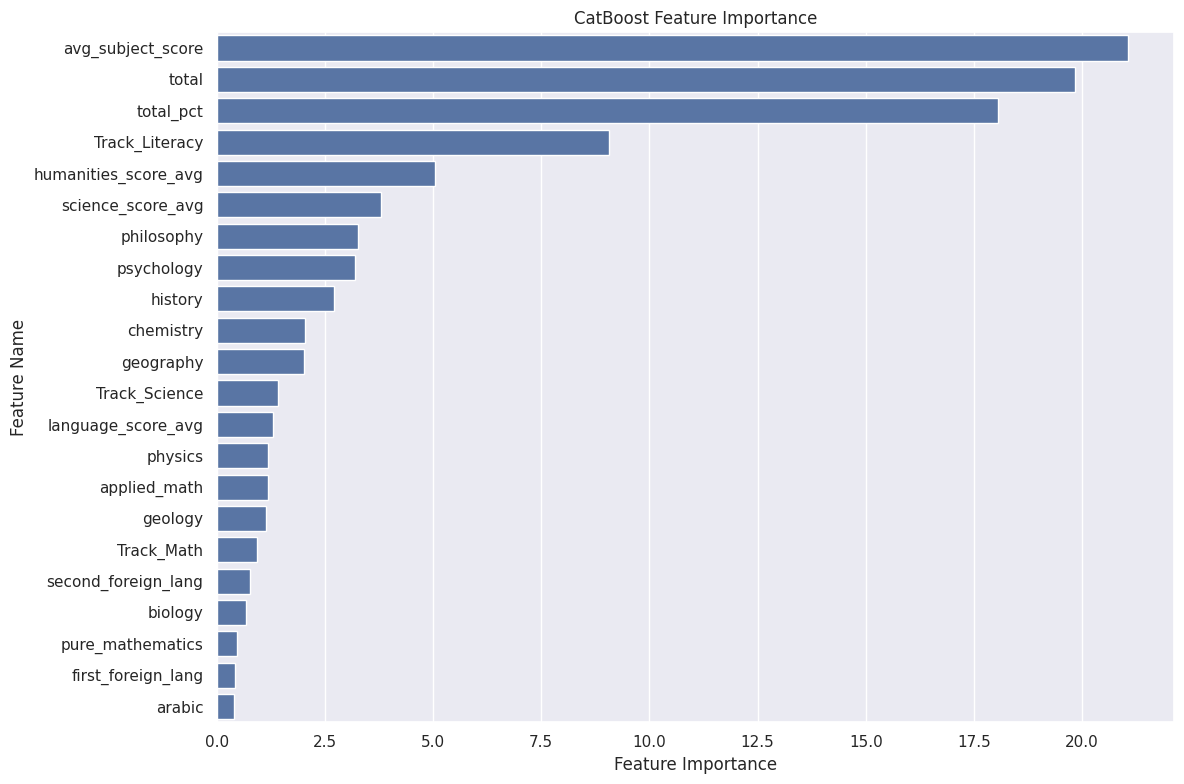

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get the CatBoost classifier from the cat_pipeline
cat_classifier = cat_pipeline.named_steps['classifier']

# Get feature names by applying the CatBoost preprocessing steps to the training data
# We fit_transform on X_train to get the actual column names after preprocessing
X_processed_cat = cat_pipeline[:-1].fit_transform(X_train, y_train_enc)
feature_names_for_importance_cat = X_processed_cat.columns.tolist()

# Get feature importances from CatBoost
# CatBoost's get_feature_importance() returns an array, which we can convert to a Series
importances_cat = cat_classifier.get_feature_importance()

# Create a DataFrame for better visualization
feature_importance_df_cat = pd.DataFrame({
    'Feature': feature_names_for_importance_cat,
    'Importance': importances_cat
})

# Sort by importance
feature_importance_df_cat = feature_importance_df_cat.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_cat)
plt.title('CatBoost Feature Importance')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [69]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

print("CatBoost Classification Report:")
print(classification_report(y_test_enc, y_pred_cat, target_names=label_enc.classes_, zero_division=0))

print(f"Precision (weighted): {precision_score(y_test_enc, y_pred_cat, average='weighted'):.4f}")
print(f"Recall (weighted): {recall_score(y_test_enc, y_pred_cat, average='weighted'):.4f}")
print(f"F1-score (weighted): {f1_score(y_test_enc, y_pred_cat, average='weighted'):.4f}")

CatBoost Classification Report:
                               precision    recall  f1-score   support

                  Agriculture       1.00      1.00      1.00       111
    Applied Health Technology       1.00      1.00      1.00        14
    Aquaculture and Fisheries       1.00      1.00      1.00        12
                  Archaeology       1.00      1.00      1.00       115
                         Arts       0.99      1.00      0.99       258
                     Commerce       1.00      1.00      1.00       310
    Computers and Information       1.00      0.97      0.99        35
                 Dar Al-Uloom       1.00      1.00      1.00        31
Disability and Rehabilitation       1.00      0.77      0.87        13
    Early Childhood Education       1.00      1.00      1.00       213
                    Economics       0.99      0.99      0.99        93
                    Education       0.99      1.00      1.00       551
                  Engineering       1.00    

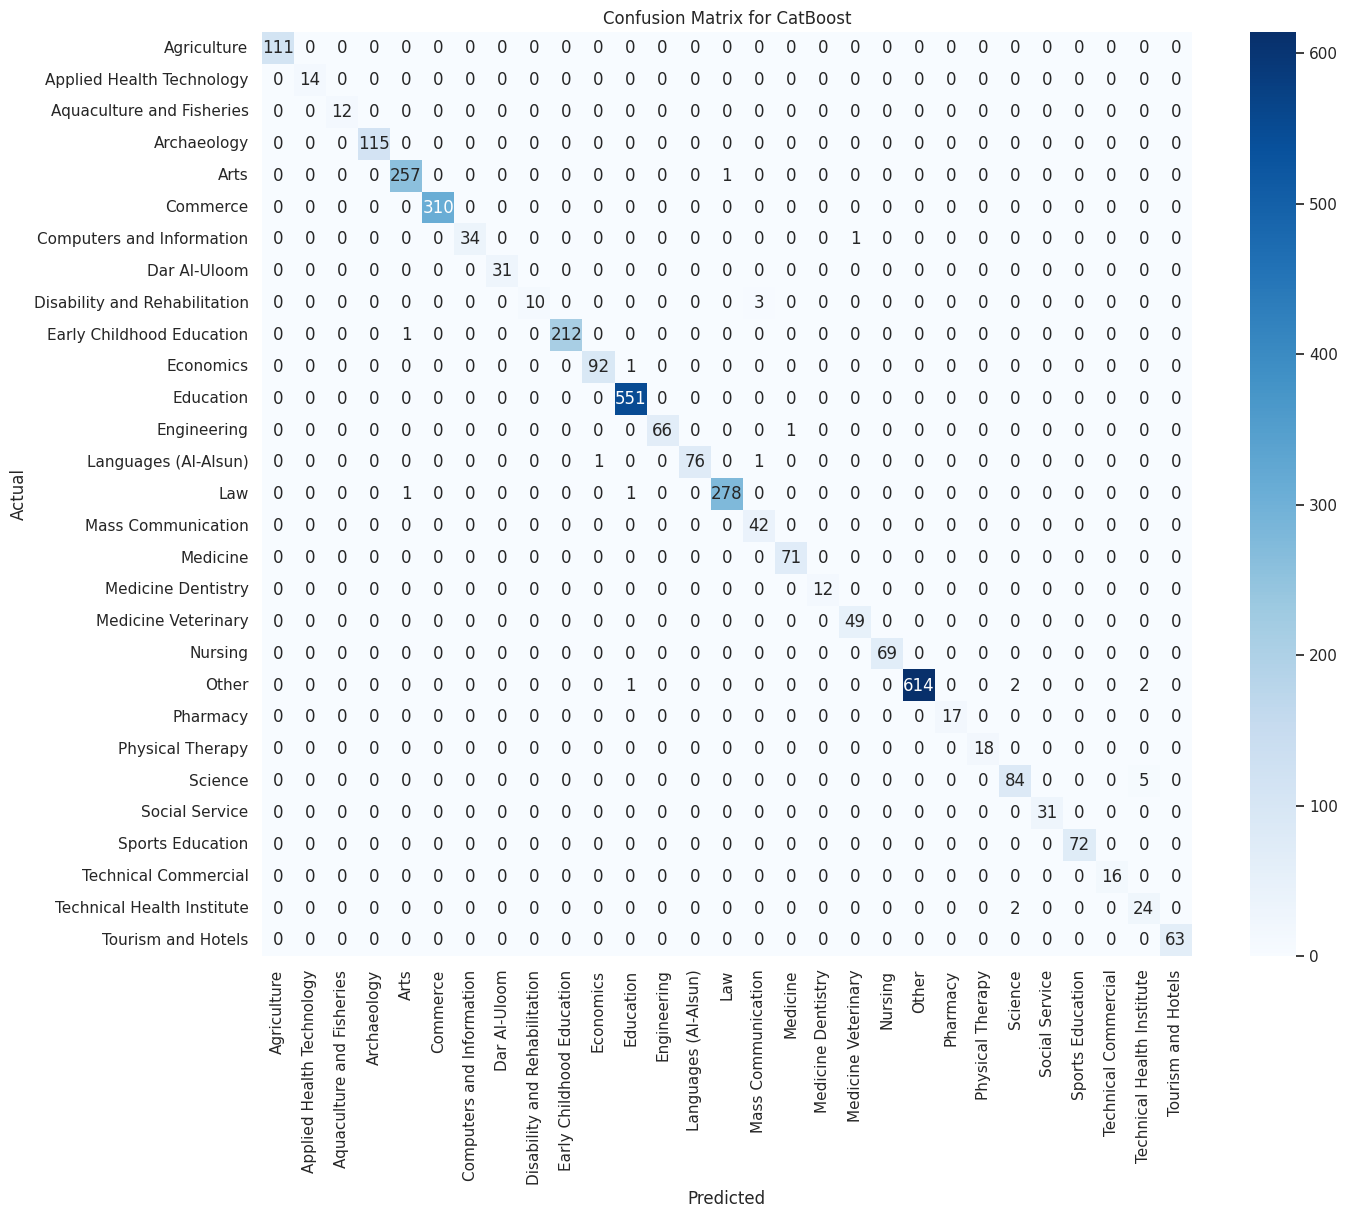

In [70]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_cat = confusion_matrix(y_test_enc, y_pred_cat)

plt.figure(figsize=(15, 12))
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Blues', xticklabels=label_enc.classes_, yticklabels=label_enc.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for CatBoost')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

Showing the How many correctly predicted from the actual

In [71]:
correct_predictions_cat = cm_cat.diagonal()
class_labels = label_enc.classes_

print("Correctly Predicted vs. Actual for CatBoost (from Confusion Matrix):")
for i, label in enumerate(class_labels):
    total_actual = cm_cat.sum(axis=1)[i]
    print(f"  {label:30}: Correctly Predicted = {correct_predictions_cat[i]:<5} (Total Actual = {total_actual})")

Correctly Predicted vs. Actual for CatBoost (from Confusion Matrix):
  Agriculture                   : Correctly Predicted = 111   (Total Actual = 111)
  Applied Health Technology     : Correctly Predicted = 14    (Total Actual = 14)
  Aquaculture and Fisheries     : Correctly Predicted = 12    (Total Actual = 12)
  Archaeology                   : Correctly Predicted = 115   (Total Actual = 115)
  Arts                          : Correctly Predicted = 257   (Total Actual = 258)
  Commerce                      : Correctly Predicted = 310   (Total Actual = 310)
  Computers and Information     : Correctly Predicted = 34    (Total Actual = 35)
  Dar Al-Uloom                  : Correctly Predicted = 31    (Total Actual = 31)
  Disability and Rehabilitation : Correctly Predicted = 10    (Total Actual = 13)
  Early Childhood Education     : Correctly Predicted = 212   (Total Actual = 213)
  Economics                     : Correctly Predicted = 92    (Total Actual = 93)
  Education             

# Comparison Between Models

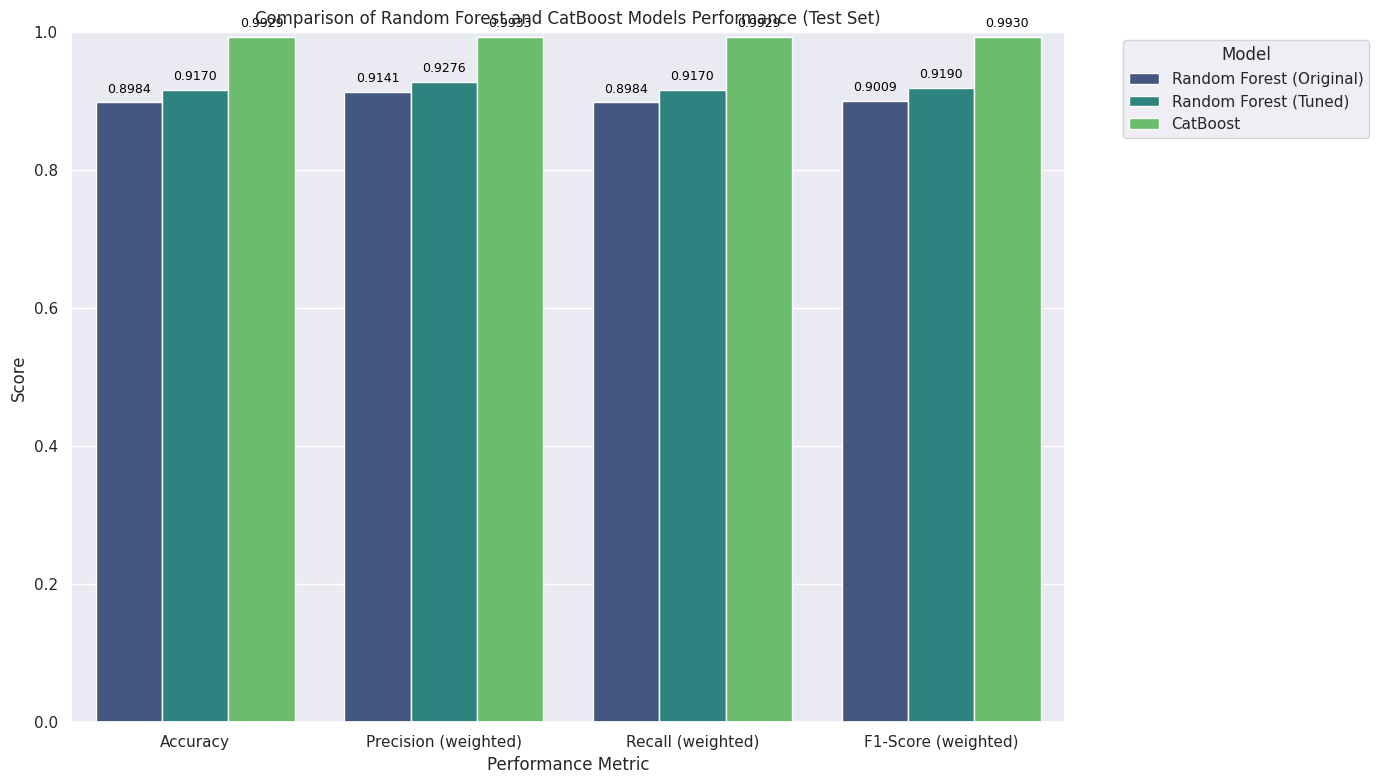

In [88]:
# Calculate metrics for CatBoost
accuracy_cat = accuracy_score(y_test_enc, y_pred_cat)
precision_cat = precision_score(y_test_enc, y_pred_cat, average='weighted', zero_division=0)
recall_cat = recall_score(y_test_enc, y_pred_cat, average='weighted', zero_division=0)
f1_cat = f1_score(y_test_enc, y_pred_cat, average='weighted', zero_division=0)

# Create a DataFrame for CatBoost metrics
catboost_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1-Score (weighted)'],
    'CatBoost': [accuracy_cat, precision_cat, recall_cat, f1_cat]
})



# Merge CatBoost metrics into the comparison DataFrame
comparison_df_full = comparison_df.merge(catboost_metrics, on='Metric')

# Melt the DataFrame for easier plotting with seaborn
comparison_melted_full = comparison_df_full.melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(14, 8))
sns.barplot(x='Metric', y='Score', hue='Model', data=comparison_melted_full, palette='viridis')
plt.title('Comparison of Random Forest and CatBoost Models Performance (Test Set)')
plt.xlabel('Performance Metric')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are typically between 0 and 1

# Add text labels on top of the bars
for container in plt.gca().containers:
    for i, bar in enumerate(container):
        value = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{value:.4f}', ha='center', va='bottom', fontsize=9, color='black')

plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Choosing the model for the recommender

CatBoost scored notably higher on the held-out test set than the tuned Random Forest. `final_model_pipeline` below is what `recommend_top_faculties` actually calls -- swap the assignment to compare the other model.

In [76]:
# best_rf       -> tuned Random Forest (cell above tuning section)
# cat_pipeline   -> CatBoost
# Swap this line to switch models; recommend_top_faculties() only needs
# `final_model_pipeline` to expose .predict_proba and a 'classifier' step.
final_model_pipeline = cat_pipeline

print('Using', type(final_model_pipeline.named_steps["classifier"]).__name__, 'as the final model.')

Using CatBoostClassifier as the final model.


## Recommendation System

A hybrid recommender for a brand-new student (their grades, `Track`, `Skills`, `Interests`):

1. **Model-based score** — run the new student through `final_model_pipeline.predict_proba` to get a probability per `Faculty_Category`.
2. **Content-based similarity score** — compare the student's Skills/Interests multi-hot vector, via cosine similarity, against the *average* Skills/Interests profile of students already in each `Faculty_Category` (computed from the training data only, via `profile_pipeline`/`faculty_profiles` below).
3. **Combined score** — a weighted blend of the two (`model_weight=0.7`, `similarity_weight=0.3` by default), returning the top 3 faculties.

Note `profile_pipeline` is a *separate* pipeline from the classifier's `build_preprocessing_steps()` — the classifier never sees Skills/Interests, but the recommender does.

In [77]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.pipeline import Pipeline

def build_profile_steps():
    """Profile pipeline for the RECOMMENDER only -- keeps Skills/Interests
    multi-hot encoded for content-based similarity. Kept separate from
    build_preprocessing_steps()/build_catboost_preprocessing_steps() so the
    classifier still never sees Skills/Interests.

    Order matters: TextToList must run before the TopKMultiHotEncoders, since
    TopKMultiHotEncoder.fit() expects list-valued cells, not raw strings.
    """
    return build_shared_steps() + [
        ('text_to_list', TextToList(['Skills', 'Interests'])),
        ('skills_mh', TopKMultiHotEncoder(list_col='Skills', prefix='skill', k=30)),
        ('interests_mh', TopKMultiHotEncoder(list_col='Interests', prefix='interest', k=30)),
        ('drop_raw_text', DropRawTextCols(['Skills', 'Interests'])),
    ]

# Full training rows (includes Skills/Interests, unlike X_train which only
# has feature_cols_raw) so the profile pipeline has something to encode.
X_full_train = data.loc[X_train.index].copy()

profile_pipeline = Pipeline(build_profile_steps())
Xtr_profiles = profile_pipeline.fit_transform(X_full_train)

full_skill_interest_cols = [
    c for c in Xtr_profiles.columns if c.startswith('skill_') or c.startswith('interest_')
]

# Grouped by the raw faculty name (y_train), not the encoded label, since
# recommend_top_faculties() looks faculty profiles up by name.
faculty_profiles = Xtr_profiles[full_skill_interest_cols].groupby(y_train.values).mean()

print('Encoded skill/interest columns:', len(full_skill_interest_cols))
print('Faculty profiles shape:', faculty_profiles.shape)

Encoded skill/interest columns: 62
Faculty profiles shape: (29, 62)


In [78]:
from sklearn.metrics.pairwise import cosine_similarity

print('Faculty profiles shape:', faculty_profiles.shape)

def recommend_top_faculties(student_raw, top_n=3, model_weight=0.7, similarity_weight=0.3):
    """
    student_raw example:
    {
        'Track': 'Science',
        'arabic': 60, 'first_foreign_lang': 40, 'second_foreign_lang': 32,
        'chemistry': 50, 'biology': 45, 'geology': 48, 'physics': 47,
        'Skills': 'Critical Thinking, Problem Solving',
        'Interests': 'Technology, Science'
    }
    Returns a list of (faculty_name, combined_score) of length `top_n`, sorted descending.

    Blends two signals:
      1. Model-based score: final_model_pipeline.predict_proba per Faculty_Category.
      2. Content-based similarity: cosine similarity between the student's
         Skills/Interests multi-hot vector and each Faculty_Category's average
         profile (from profile_pipeline / faculty_profiles, training data only).
    """
    # Base row shared by both pipelines
    base_row = {col: student_raw.get(col, np.nan) for col in SUBJECT_COLS}
    base_row['Track'] = student_raw['Track']
    base_row['total'] = student_raw.get('total', np.nan)  # placeholder; FeatureEngineer recomputes it

    # --- Model-based score (classifier pipeline) ---
    Xnew_classifier_input = pd.DataFrame([base_row])[feature_cols_raw]
    model_proba = final_model_pipeline.predict_proba(Xnew_classifier_input)[0]

    model_classes = label_enc.inverse_transform(
        final_model_pipeline.named_steps['classifier'].classes_.astype(int)
    )
    model_scores = pd.Series(model_proba, index=model_classes)

    # --- Content-based similarity score (profile pipeline) ---
    Xnew_profile_input_row = base_row.copy()
    Xnew_profile_input_row['Skills'] = student_raw.get('Skills', '')
    Xnew_profile_input_row['Interests'] = student_raw.get('Interests', '')
    Xnew_profile_input = pd.DataFrame([Xnew_profile_input_row])

    Xnew_profile = profile_pipeline.transform(Xnew_profile_input)

    if len(full_skill_interest_cols) > 0 and not faculty_profiles.empty:
        student_vec = Xnew_profile[full_skill_interest_cols].values
        sims = cosine_similarity(student_vec, faculty_profiles.values)[0]
        sim_scores = pd.Series(sims, index=faculty_profiles.index)
        if sim_scores.max() > 0:
            sim_scores = sim_scores / sim_scores.max()
    else:
        sim_scores = pd.Series(0.0, index=model_scores.index)

    all_faculties = model_scores.index.union(sim_scores.index)
    model_scores = model_scores.reindex(all_faculties, fill_value=0)
    sim_scores = sim_scores.reindex(all_faculties, fill_value=0)

    combined = (model_weight * model_scores + similarity_weight * sim_scores).sort_values(ascending=False)
    return list(combined.head(top_n).items())

Faculty profiles shape: (29, 62)


### Example: recommend the top 3 faculties for a new student

In [79]:
example_student = {
    'Track': 'Science',
    'arabic': 60, 'first_foreign_lang': 40, 'second_foreign_lang': 15,
    'chemistry': 20, 'biology': 60, 'geology': 48, 'physics': 47,
    'Skills': 'Critical Thinking, Problem Solving',
    'Interests': 'Technology, Science'
}

recommendations = recommend_top_faculties(example_student, top_n=3)
print('Top 3 recommended faculties:')
for rank, (faculty, score) in enumerate(recommendations, start=1):
    print(f'  {rank}. {faculty}  (score: {score:.4f})')

Top 3 recommended faculties:
  1. Sports Education  (score: 0.7507)
  2. Computers and Information  (score: 0.3000)
  3. Engineering  (score: 0.2705)


### Program recommendataion and skill Gap Analysis

In [80]:
df = pd.read_csv("/content/AllSkillsRequiredwithTansiq.csv")

print(df.head())

                        Track       College_University_AR  \
0  Scientific - Science Track                 طب المنصورة   
1  Scientific - Science Track  هندسة بترول و تعدين السويس   
2  Scientific - Science Track                    طب سوهاج   
3  Scientific - Science Track                    طب دمياط   
4  Scientific - Science Track                 طب الزقازيق   

                   College_University_EN  MinScore_2022_out_of_410  \
0                      Medicine Mansoura                     387.0   
1  Engineering Petroleum and Mining Suez                     386.0   
2                         Medicine Sohag                     386.0   
3                      Medicine Damietta                     386.0   
4                       Medicine Zagazig                     385.0   

   Percentage                                  KeySkillsRequired  
0       94.39  High focus and memorization, empathy and human...  
1       94.15  Advanced math and physics, geological analysis...  
2       94.

In [81]:
# Create one text document for every row
df["rag_text"] = (
    "Program: " + df["College_University_EN"].astype(str) +
    ". Required Skills: " + df["KeySkillsRequired"].astype(str)
)

print(df["rag_text"].head())

0    Program: Medicine Mansoura. Required Skills: H...
1    Program: Engineering Petroleum and Mining Suez...
2    Program: Medicine Sohag. Required Skills: High...
3    Program: Medicine Damietta. Required Skills: H...
4    Program: Medicine Zagazig. Required Skills: Hi...
Name: rag_text, dtype: object


In [82]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

texts = df["rag_text"].tolist()

embeddings = embedding_model.encode(
    texts,
    convert_to_numpy=True
).astype("float32")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [83]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 103.9 MB/s eta 0:00:00


In [84]:
import faiss

dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(embeddings)

print("Number of programs:", index.ntotal)

Number of programs: 1286


In [85]:
# Test the search
query = "I have strong Biology and Chemistry skills."

query_embedding = embedding_model.encode(
    [query],
    convert_to_numpy=True
).astype("float32")
k = 3
distances, indices = index.search(query_embedding, k)
results = df.iloc[indices[0]]
print(results[["College_University_EN", "KeySkillsRequired"]])

    College_University_EN                                  KeySkillsRequired
583    Science Alexandria  Analytical scientific thinking, math/chemistry...
153    Science Alexandria  Analytical scientific thinking, math/chemistry...
689    Science Alexandria  Analytical scientific thinking, math/chemistry...


In [86]:
# Skill Gap Analysis
student_skills = [
    "Biology",
    "Chemistry",
    "Communication"
]

program = results.iloc[0]

required_skills = [
    skill.strip()
    for skill in program["KeySkillsRequired"].split(",")
]

missing_skills = sorted(
    set(required_skills) - set(student_skills)
)

print("Recommended Program:")
print(program["College_University_EN"])

print("\nMissing Skills:")
print(missing_skills)

Recommended Program:
Science Alexandria

Missing Skills:
['Analytical scientific thinking', 'math/chemistry/physics depending on department', 'scientific research']


In [87]:
import joblib

joblib.dump(final_model_pipeline, 'final_model_pipeline.pkl')
joblib.dump(label_enc, 'label_enc.pkl')
joblib.dump(profile_pipeline, 'profile_pipeline.pkl')
joblib.dump(faculty_profiles, 'faculty_profiles.pkl')

joblib.dump({
    'feature_cols_raw': feature_cols_raw,
    'SUBJECT_COLS': SUBJECT_COLS,
    'full_skill_interest_cols': full_skill_interest_cols,
}, 'recommender_config.pkl')

print('Saved 5 files for deployment.')

Saved 5 files for deployment.


### Note:
# Final Model Development

> **Final Edition**

This notebook represents the **final version** of the machine learning pipeline after multiple rounds of experimentation and improvement.

Throughout the development process, several approaches were tested and refined, including:

- Multiple preprocessing strategies
- Feature engineering improvements
- Feature selection techniques
- Handling class imbalance
- Hyperparameter tuning
- Model comparison and evaluation
- Preventing data leakage
- Performance optimization

Several iterations were conducted, and different techniques were evaluated before selecting the final pipeline presented in this notebook. The final solution was chosen because it achieved the best balance between predictive performance, generalization, and model reliability.